<!-- SPDX-License-Identifier: Apache-2.0 -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sscs-ose/sscs-ose-code-a-chip.github.io/blob/main/ISSCC27/submitted_notebooks/ascon_glitch_leakage/ascon_glitch_leakage.ipynb)

Run the submitted version now, before the organizers merge it: [open it in Colab from the author's
repository](https://colab.research.google.com/github/Sarkar22/ascon-glitch-leakage/blob/main/notebook/ascon_glitch_leakage.ipynb).

# Safe on Paper, Leaky in SPICE
### Pre-silicon glitch-leakage assessment of a masked Ascon S-box on SkyWater sky130, at three fidelity levels

**IEEE SSCS Code-a-Chip, ISSCC 2027** &nbsp;|&nbsp; License: Apache-2.0 (see `LICENSE`) &nbsp;|&nbsp;
Tools: ngspice-42, sky130A (open_pdks `0fe599b2afb6708d281543108caf8310912f54af`), Icarus Verilog, OpenLane v1 (Yosys, OpenROAD, Magic,
KLayout, Netgen), Python, NumPy, Matplotlib

**Versions.** ngspice-42 for every SPICE campaign; live mode installs Ubuntu 22.04's ngspice-36 from
apt, which matched the ngspice-42 reference within 5e-5 µA (§3.4, "How to run"). sky130A at open_pdks
`0fe599b2afb6708d281543108caf8310912f54af`, installed with ciel 3.0.0. OpenLane v1 at commit `ff5509f`. Icarus Verilog 11
or 12. Python 3.10 to 3.12 with NumPy and Matplotlib.

| Name | Affiliation | Role | IEEE member | SSCS member | Contact |
|---|---|---|---|---|---|
| Emon Sarkar | University of Waterloo, Electrical and Computer Engineering | author | yes | no | esarkar@uwaterloo.ca |

## The claim, on one screen

**A first-order masked Ascon S-box in which a zero-delay model finds no leak does leak at first order in
transistor-level SPICE on sky130, before and after place and route** (OpenLane; DRC and LVS clean, and both checks
fail on injected faults; capacitance-only extraction). The leak is in the *timing* of the unregistered
logic (glitches, in the broad sense of §2.4), and an exact glitch-extended probing check flags the nets that carry it
in seconds. With DOM's register barrier moved *behind* Ascon's input affine layer (DA), no net is flagged and no
first-order leak shows up within 19,997 traces before layout or 9,997 after it. That is a bound, not a proof:
at these counts TVLA reaches 4.5 on average for a leak 0.24 times as strong as N's before layout, and
0.39 times after it (at half the traces). A profiled attack on the same traces, designed after the
kill test, recovers N's two key bits once its points of interest are chosen per key bit (§5). The fix costs
59 % more cell area, 39 % more energy per evaluation before layout
(60 % after layout, clock tree included), 2 cycles of latency instead of
1 (+13 % in time) and no extra randomness (§7). This is
noiseless simulation with an ideal supply at one corner (tt, 27 °C, 1.8 V), not silicon (§8).

| Variant | glitch-extended probing: insecure nets | zero-delay model | timing-aware model | SPICE | SPICE after place and route |
|---|---|---|---|---|---|
| **N**: masked, no register barrier | 39 of 103 | 1.08 (secure) | 12.1 | **13.2** at 9,998: **leaks** | **8.19** at 4,998: **leaks** (before layout, same rows: 8.07) |
| **D**: DOM, barrier in the textbook place | 12 of 133 | 2.11 (secure) | 16.7 | 3.08 at 19,997: not seen (net-level leak, §4.4) | not laid out |
| **DA**: DOM, barrier after the affine layer | 0 of 133 | 2.71 (secure) | 2.96 | 3.08 at 19,997: none detected | 3.36 at 9,997: none detected (before layout, same rows: 3.35) |
| *Control:* U, unmasked | - | 27.7 | 38.4 | 37.4 at 1,998: leaks | - |
| *Control:* N, masks forced to zero | - | 19.2 | 28.1 | 27.5 at 998: leaks | - |
| *Control:* N, random vs random | - | 0.60 | 3.12 | 1.87 at 9,998: none | - |

Numbers are max\|t\| of first-order fixed-vs-random TVLA at the given trace count (> 4.5 = leak); the two models run on
the SPICE rows (worst of three toggle weightings). The controls show that the test finds a leak where there must be one
and none where there is none. D and DA end at the same max\|t\| (3.08) at the same sample (2.175 ns, in
the first cycle's clock-fall region). The likely source is circuitry the two variants share, so the two values are
probably one observation, not two (§4.5).

**Reading guide.** (1) This screen and Figures 1 and 2. (2) The evidence: §4.1 (N leaks; why the zero-delay model
cannot see it), §4.4 and §4.5 (D and DA), §6 (layout and the registered post-layout test), §7 (cost); criteria were
registered before the data existed (§3.6, §6.2). (3) Check it: run the notebook (cached under a minute, live about
3 minutes in a 2-CPU Ubuntu 22.04 container; "How to run"), `data/MANIFEST.csv`, and the registrations
and reviews in the [project repository](https://github.com/Sarkar22/ascon-glitch-leakage/tree/main/docs).

In [1]:
# SPDX-License-Identifier: Apache-2.0
# Setup. On Colab this notebook's folder is fetched first: the sscs-ose
# copy once it is merged, else the author's public repository at REPO_REF
# (a branch or tag). setup_env.setup() then finds (on Colab: installs)
# ngspice and the sky130 PDK and picks the mode: 'live' when every tool
# is there, else 'cached' (plots the data/ folder only).
import os
import subprocess
import sys

UPSTREAM = 'https://github.com/sscs-ose/sscs-ose-code-a-chip.github.io'
FOLDER = 'ISSCC27/submitted_notebooks/ascon_glitch_leakage'
REPO = 'https://github.com/Sarkar22/ascon-glitch-leakage'
REPO_REF = os.environ.setdefault('ASCON_REPO_REF', 'main')
if 'google.colab' in sys.modules and not os.path.exists('nbdata.py'):
    GIT = ['git', 'clone', '-q', '--depth', '1']
    HOME = os.path.join('code-a-chip', FOLDER)
    if not os.path.isdir('code-a-chip'):
        subprocess.run(GIT + ['--filter=blob:none', '--sparse', UPSTREAM,
                              'code-a-chip'])
        subprocess.run(['git', '-C', 'code-a-chip', 'sparse-checkout',
                        'set', FOLDER])
    if not os.path.exists(os.path.join(HOME, 'nbdata.py')):
        HOME = os.path.join('ascon-glitch-leakage', 'notebook')
        if not os.path.isdir(HOME):
            subprocess.run(GIT + ['--branch', REPO_REF, REPO,
                                  'ascon-glitch-leakage'], check=True)
    os.chdir(HOME)
sys.path.insert(0, os.getcwd())
import setup_env              # the environment helper in this folder
import nbanim
import nbdata
import nbexplorer
import nbfigs

ENV = setup_env.setup()       # prints what it found
MODE = ENV.mode
H = nbdata.fmt_headline()
print('run mode:', MODE, '| data from', nbdata.source() + '/',
      '| results dated', H['results_dated'])

mode         cached  (ngspice not installed; no sky130A PDK found (looked in ~/.ciel/sky130A))
platform     linux
python       3.10.21
numpy        2.2.6
matplotlib   3.10.9
ngspice      -
iverilog     -
PDK          -
repository   ..
cached data  data


run mode: cached | data from data/ | results dated 2026-09-25 to 2026-09-26


**Figure 1.** Welch \|t\| of the DUT's supply current against time, for the three masked variants, from the
per-sample t-curves in `data/tcurve_*.csv` (copies of [`results/kill_test/`](https://github.com/Sarkar22/ascon-glitch-leakage/tree/main/results/kill_test)). The zero-delay model has no time axis: it gives
one value per row (green line). N's window is one 4 ns clock cycle; D and DA take two cycles (second edge at 4 ns).
D's and DA's curves end at the same max\|t\| at the same sample (2.175 ns), probably from circuitry the two
variants share: one observation, not two (§4.5).

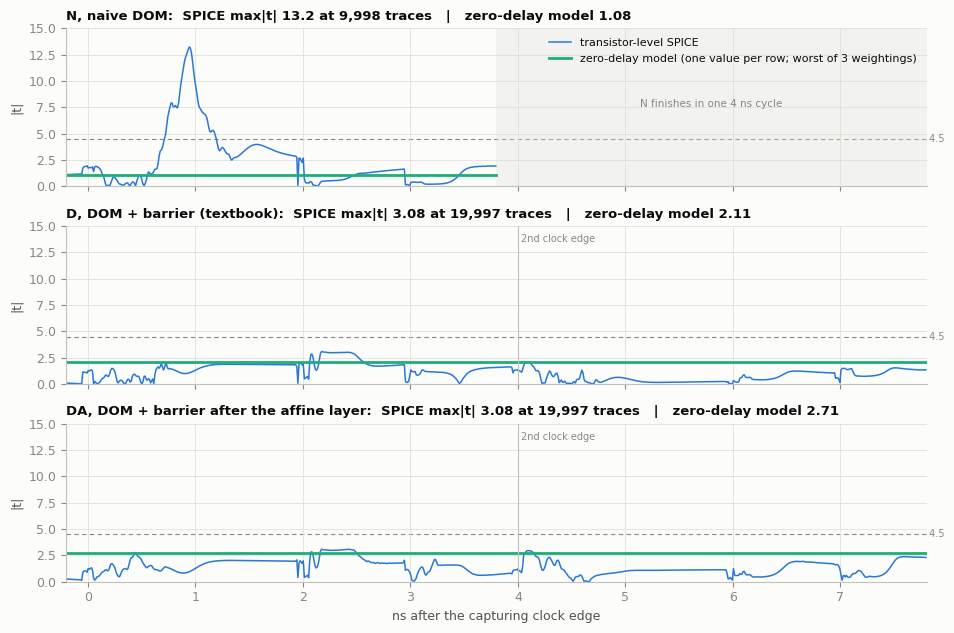

In [2]:
nbfigs.show(nbfigs.headline())

**Figure 2.** The workflow. One generator writes one netlist per variant. Four views of it (the exact probing check,
the zero-delay and timing-aware models, and transistor-level SPICE, which also runs on the extracted layouts of N and
DA) feed one statistic, first-order TVLA.

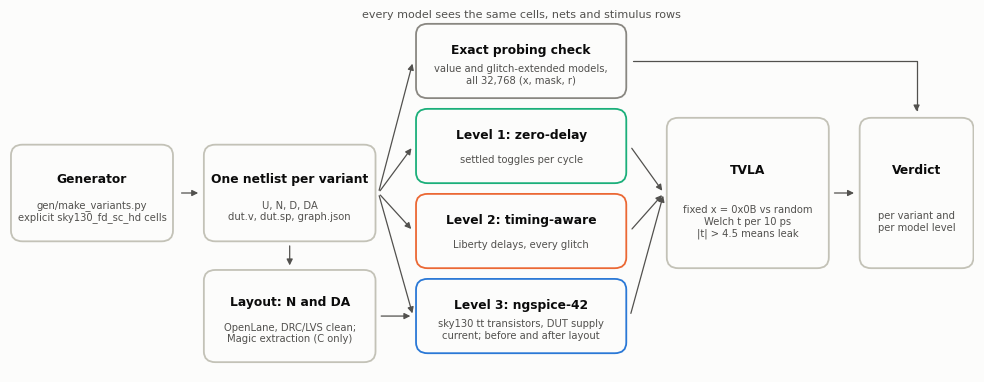

In [3]:
nbfigs.show(nbfigs.workflow())

## Abstract

Masking is the standard countermeasure against power side-channel attacks. Ascon is the lightweight cipher
that NIST standardized for constrained devices (SP 800-232). A standard digital flow checks a masked netlist only
in zero-delay (RTL or functional gate-level) simulation, which cannot see glitches; the glitch-extended probing model [6] and
checkers built on it [7, 8] exist but are not part of that flow. We build one masked Ascon
S-box column from explicit `sky130_fd_sc_hd` cells in four variants: unmasked (U), naive domain-oriented masking
without a register barrier (N), DOM with its register barrier in the textbook place (D), and DOM with the barrier
after Ascon's input affine layer (DA). We assess the *same* netlists at three fidelity levels: a zero-delay
toggle model, a timing-aware gate-level model with Liberty delays, and transistor-level ngspice simulation with
the sky130 foundry models. An exact probing check (value and glitch-extended models) runs alongside. The test protocol
was written down before any SPICE trace existed (pre-registered): fixed-vs-random TVLA with fresh masks in every
row. N is secure in the zero-delay model (max\|t\| 1.08) but leaks in SPICE (13.2 at 9,998 traces). The leak
sits in the evaluation, 0.945 ns after the clock edge. The nets whose own transitions carry it are nets
that glitch-extended probing flags. Textbook DOM (D) still fails the probing check, because Ascon's affine layer
sits between its input registers and its AND gates. Its net-level leak is visible in SPICE node voltages, but it
does not show in the supply current at 19,997 traces, where the timing-aware model predicts max\|t\| 15.2
(cap-weighted; 16.7 with the worst of three weightings). DA passes the probing check and shows no first-order leak at
19,997 traces. N and DA were then placed and routed with OpenLane (DRC, LVS and antenna clean; the generator's cells
unchanged) and extracted with Magic (capacitance only). A post-layout test, registered with fixed trace counts while
the campaigns were running, gives the same verdicts on the same stimulus rows (for DA at half the traces): N still leaks (8.19 at 4,998 traces; 8.07 before
layout), 0.69 ns later, and DA shows no first-order leak at 9,997 traces (3.36). A profiled template attack on the same traces, run after the kill test, recovers N's two key bits at
first order (success rate 0.93 at 765 attack traces per key) once one point of interest is chosen per
key bit; that choice was made after the default attack had missed one key bit (default success rate 0.62). It
finds no first-order key in D or DA, where it would detect a leak 0.35-0.5 times as strong as N's (TVLA: about
0.24). The fix costs 59 % more cell area and 39 % more energy per
evaluation in the simulated supply current than N (46 % with an estimate of the flip-flops' clock-pin
charge; both for pipelined use), and no extra randomness; after layout, 61 % more core area and
60 % more energy per evaluation with the clock tree in the simulated supply. Every step uses open
tools and an open PDK. Every result number in this text is read from a committed file of the project repository (the
result files, the registrations, the reviews and, for the clock tree's insertion delay, [`layout/README.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/layout/README.md)). The run
times in "How to run" and the ngspice-36 comparison in the version line are wall-clock and live-path
measurements, not results.

## Contents

| § | Section | What it answers |
|---|---|---|
| 1 | Motivation | Why masked Ascon, why at the edge, why pre-silicon |
| 2 | Background | Ascon S-box, Boolean masking, DOM, glitches, probing models, TVLA |
| 3 | Method | Four variants, one netlist, three models, the protocol and its pre-registration |
| 4 | Results | N leaks; one clock cycle animated; which nets; D; DA; how far the cheap models go; noise; an explorer |
| 5 | Key recovery | What a profiled attacker gets from N, D and DA, and what "no first-order key recovery" rules out |
| 6 | Layout and post-layout | N and DA through OpenLane, extraction and SPICE: does the leak survive place and route, and does the fix? Do the sign-off checks catch faults, and what does resistance change? |
| 7 | Cost of the fix | Area, energy, latency and randomness of U, N, D and DA (pre-layout), and N and DA after layout |
| 8 | Limitations | What these numbers do and do not show |
| 9 | Conclusion | Summary and next steps |
| 10 | References | With DOIs |

## How to run

| Path | What runs | Time |
|---|---|---|
| **Cached** (default; also what CI runs) | Reads the notebook's data set (`data/`, CSV files and a few JSON summaries, listed with hashes in `data/MANIFEST.csv`) and draws every figure, table and the explorer | under 1 min |
| **Live** (Colab, or any Linux with the setup helper) | Also fetches the code, installs ngspice and iverilog (apt) and the pinned sky130 PDK (ciel), regenerates the netlists, re-derives the animation from the level-2 model, and simulates 60 clock cycles of N with its masks forced to zero in ngspice, checked against the shipped ngspice-42 reference (§3.4). [`colab_check.py`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/notebook/colab_check.py) also re-runs the probing check and the level-1/2 models | about 3 min: fetch 2 s; installs 38 s (apt 14 s, pip install ciel 3 s, PDK 20 s); then the notebook 139 s, of which the SPICE demo takes 93 s and the animation 40 s. Measured in one run in an Ubuntu 22.04 container with 2 CPUs ([`tests/colab_live.sh`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/notebook/tests/colab_live.sh)) |
| **Full reproduction** (outside the notebook) | All SPICE campaigns of §4, with the commands in [`docs/KILL_TEST.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/KILL_TEST.md) ("Reproduce"); then the key recovery of §5 ([`analysis/key_recovery.py`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/analysis/key_recovery.py)), the layouts and post-layout campaigns of §6 ([`layout/README.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/layout/README.md), [`docs/POSTLAYOUT.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/POSTLAYOUT.md)) and the cost table of §7 ([`analysis/cost_table.py`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/analysis/cost_table.py)) | 6.5 h of wall clock for the first run (10 ngspice processes on one laptop), plus about 18 h on 6 CPUs to extend DA and D to 20,000 rows; the key recovery about 25 min with 3 processes; the two post-layout campaigns 8.9 h of wall clock on 6 CPUs, including a pause while the laptop was suspended |

Run the cells top to bottom. The first code cell chooses the mode and prints what it found. On Colab it first
fetches this folder: from sscs-ose once the entry is merged, until then from the author's public repository at the
ref in `REPO_REF` (https://github.com/Sarkar22/ascon-glitch-leakage/tree/main). Every figure is drawn from `data/`, which [`make_cached_data.py`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/notebook/make_cached_data.py) exports from
[`results/`](https://github.com/Sarkar22/ascon-glitch-leakage/tree/main/results) and the SPICE runs. A review re-ran the kill
test's reproduction and got its [`results/`](https://github.com/Sarkar22/ascon-glitch-leakage/tree/main/results) bit for bit ([`docs/reviews/repro-code.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/reviews/repro-code.md)); the layout and post-layout
steps of §6 were not re-run that way.

## 1. Motivation

**Edge devices need cryptography that survives physical access.** A sensor node, a medical patch or a
car's control unit runs its cipher where an attacker can put a probe on the supply pin. The attacker then
correlates the current with the data. This is differential power analysis. Masking is the standard answer: every
secret-dependent value is split into random shares, so that no single wire carries information about the secret.
The ISSCC 2027 theme, *Trusted Sustainable Silicon Intelligence from Edge to Cloud*, asks for exactly this kind
of trust at the edge.

**Ascon is now the lightweight standard.** NIST standardized the Ascon family in SP 800-232 [2] for constrained
devices. Its 5-bit S-box has algebraic degree 2, so a masked Ascon needs only five masked AND gates per S-box
column. That is why Ascon is the textbook case for low-cost masking [1, 11].

**The gap is between the model and the circuit.** Masking is proven secure in a model where every wire
settles once per cycle. Real CMOS gates see their inputs arrive at different times: an output can switch
briefly before it settles (a *glitch*), and *when* it switches can depend on the data. Mangard et al. showed in
2005 that glitches break masked gates [3]. The fixes are threshold implementations [4] and
domain-oriented masking (DOM) with a register barrier [5], and the checks are the robust (glitch-extended) probing
model [6] and tools such as SILVER [7] and PROLEAD [8]. A zero-delay or RTL simulation, the check that a
standard digital flow provides, cannot see any of these effects. Unprotected Ascon hardware is known to fall to
power analysis [14].

**What this notebook adds.** On an open PDK and with open tools only, we take *one* netlist per variant through
four views: an exact probing check, a zero-delay model, a timing-aware model and transistor-level SPICE. We then
ask three things. Does the leak that theory predicts appear in the foundry transistor models? Which cheap model
predicts it? And what does the fix need, and cost, in a real Ascon datapath? The test protocol was fixed before
the first SPICE trace (§3.6), and the negative results are reported as they came out. The design rule that comes
out of it, DOM's register barrier after Ascon's input affine layer, follows from DOM's condition that the two inputs of
each masked AND be independent [5] (§2.3); the contribution here is to show its consequence in transistor-level
simulation, before and after layout, on an open PDK.

## 2. Background

### 2.1 The Ascon S-box

Ascon's state is five 64-bit words; the S-box acts on one bit column $x = (x_0, x_1, x_2, x_3, x_4)$, with
$x_0$ the most significant bit. In the bitsliced form of SP 800-232 [2]:

$$
\begin{aligned}
&x_0 \mathrel{\oplus}= x_4,\quad x_4 \mathrel{\oplus}= x_3,\quad x_2 \mathrel{\oplus}= x_1 &&\text{(input affine layer)}\\
&t_i = \overline{x_i}\, x_{i+1}\quad (i = 0..4,\ \text{indices mod } 5) &&\text{(the only nonlinear part: 5 ANDs)}\\
&x_i \mathrel{\oplus}= t_{i+1} &&\\
&x_1 \mathrel{\oplus}= x_0,\quad x_0 \mathrel{\oplus}= x_4,\quad x_3 \mathrel{\oplus}= x_2,\quad x_2 = \overline{x_2} &&\text{(output affine layer)}
\end{aligned}
$$

Keep the **input affine layer** in mind. It makes the two inputs of three of the five ANDs share a variable:
$t_1 = \overline{x_1}\,(x_2 \oplus x_1)$, and similarly $t_3$ and $t_4$. That detail decides §4.4.

### 2.2 First-order Boolean masking

Each secret bit is split into two shares, $x = x^{(0)} \oplus x^{(1)}$, with $x^{(1)}$ a fresh uniform random mask.
Linear operations (XOR, NOT) work share by share; NOT acts on share 0 only. A circuit is *first-order probing
secure* [12] if the value of any single wire is statistically independent of the unshared $x$. If every wire
leaked only its own settled value, the *mean* supply current would then not depend on $x$; a first-order leak is a
dependence of the mean. The *variance* can still depend on $x$, which is why second-order tests are expected to
fail.

### 2.3 Domain-oriented masking (DOM) of an AND

Every Ascon AND has the form $z = \overline{a}\,b$ ($a = x_i$, $b = x_{i+1}$ after the affine layer). With shares
$a^{(0)}, a^{(1)}, b^{(0)}, b^{(1)}$, NOT on share 0 only, and one fresh random bit $r$ (DOM-indep [5]):

$$
z^{(0)} = \underbrace{\overline{a^{(0)}}\, b^{(0)}}_{p_{00}} \oplus
\underbrace{\big(\overline{a^{(0)}}\, b^{(1)} \oplus r\big)}_{p_{01}},
\qquad
z^{(1)} = \underbrace{a^{(1)} b^{(1)}}_{p_{11}} \oplus \underbrace{\big(a^{(1)} b^{(0)} \oplus r\big)}_{p_{10}} .
$$

The four terms XOR to $(\overline{a^{(0)}} \oplus a^{(1)})(b^{(0)} \oplus b^{(1)}) = \overline{a}\,b$. The
*cross-domain* products $m_{01} = \overline{a^{(0)}}\,b^{(1)}$ and $m_{10} = a^{(1)} b^{(0)}$ combine one share of each input. They are
refreshed with $r$, and DOM registers all four partial products before they are XORed together (integrated). The
register is the *barrier*: it stops glitches of one domain from meeting the other domain's values in the
integration XOR. This is secure only if $a$ and $b$ are independent. If they share a variable, as in $t_1$ above,
then the product $m_{01}$ sees both shares of that variable.

### 2.4 Glitches and the glitch-extended probing model

In CMOS, the supply delivers the charge $C_k V_{DD}$ when net $k$ rises. The supply current is therefore a sum of
pulses at the times $t_k$ when nets switch:
$I_{DD}(t) \approx \sum_k C_k V_{DD}\, h(t - t_k)$, where $h$ is the pulse shape of one transition. A zero-delay model counts one settled toggle per net and
cycle, and loses the times $t_k$ and every extra transition. But a glitch or a late transition happens only for
certain input *orders*, and the order depends on the data. In the **glitch-extended (robust) probing model** [6],
a probe on a combinational net sees every *stable* signal in its combinational fan-in cone (register outputs
and inputs, not crossing a register). A design is first-order secure in this model if the joint distribution of
each cone's stable signals is independent of $x$. This model covers both glitch pulses and data-dependent arrival
times. We use the word *glitch* in this broad sense: any timing effect of unregistered logic.

### 2.5 TVLA: the leakage test

Test vector leakage assessment [9, 10, 13] compares traces of a **fixed** input with traces of **random** inputs.
The two classes are interleaved at random, and the masks are fresh in every trace. At every time sample it
computes Welch's $t$:

$$
t = \frac{\mu_F - \mu_R}{\sqrt{s_F^2/n_F + s_R^2/n_R}},\qquad |t| > 4.5 \ \Rightarrow\ \text{first-order leakage}.
$$

For a true standardized difference $\delta = (\mu_F-\mu_R)/s$ and $n$ traces split evenly, $t \approx \delta\sqrt{n}/2$.
Two consequences are used throughout. First, a real leak grows like $\sqrt{n}$. Second, a run that stays below 4.5 with
$n$ traces bounds only effects of about $\delta = 9/\sqrt{n}$ and larger. That is the effect for which $t$ reaches 4.5
on average, so an effect of exactly that size is still missed about half the time. For N, $\delta_N = 0.265$ standard
deviations.

## 3. Method

### 3.1 Design under test: four variants of one S-box column

All four variants register their inputs, fresh random bits and outputs in `dfxtp_1` flip-flops. They are generated
**structurally from explicit `sky130_fd_sc_hd` cells** ([`gen/make_variants.py`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/gen/make_variants.py)). No logic synthesis runs, so no
optimizer can merge shares. Each `~a & b` is DOM-indep with its own fresh bit $r_i$ (§2.3). D registers all 20
partial products and the 10 linear terms before integration. DA is D with the input affine layer moved *in front of*
the input registers. In a round-based core, that corresponds to merging the affine layer into the previous round's
linear layer, before the state register.

In [4]:
nbfigs.show_md(nbfigs.variants_table())

Id,Structure,cells (flip-flops),latency,fresh random bits per S-box
U,unmasked,27 (10),1,0
N,naive DOM (no register barrier),88 (25),1,5
D,DOM with register barrier (textbook placement),118 (55),2,5
DA,DOM with the barrier after Ascon's affine layer,118 (55),2,5


### 3.2 One netlist, three models

One generator writes the structural Verilog (`dut.v`), the SPICE subcircuit (`dut.sp`) and a gate graph
(`graph.json`) for each variant. All models therefore describe the same cells, nets and wire capacitances.
Icarus Verilog checks every variant against the S-box with the PDK's own cell models, exhaustively and on
2,000 random rows.

* **Level 1, zero-delay** ([`model/toggle.py`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/model/toggle.py)): per clock cycle, the number of nets whose settled value
  changed, optionally weighted by the net's load capacitance. This is what an RTL or zero-delay flow can see.
* **Level 2, timing-aware** ([`model/glitch.py`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/model/glitch.py)): an event-driven simulation with per-arc delays from the sky130
  `tt` Liberty file at each net's load. Transport delay keeps every glitch, and every transition is binned in
  time on the SPICE runner's 10 ps grid.
* **Level 3, transistor level** ([`sim/spice_campaign.py`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/sim/spice_campaign.py)): ngspice [17] with the sky130 [16] `tt` models, 27 °C, 1.8 V, a
  4 ns clock and trapezoidal integration (maximum step 10 ps). The trace is the DUT's own supply current $i(V_{PWR})$
  in 10 ps bins. It is the ground truth of this study; §8 says what it leaves out.

Figure 2, on the first screen, shows the workflow.

### 3.3 The exact probing check

[`model/probing.py`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/model/probing.py) enumerates all $32^3 = 32{,}768$ combinations of unshared input, mask and fresh bits, with
the flip-flops transparent. For every net it compares the exact distributions, with no sampling and no threshold:
the net's value (value model), and the joint value of all stable signals in its combinational cone
(glitch-extended model). It runs in seconds and needs no SPICE. Its unit tests ([`model/tests/test_probing.py`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/model/tests/test_probing.py)) hold
it to verdicts derived by hand: U fails the value model and no masked variant does, D fails at exactly the
cross-domain terms (`m01`, `p01`, `m10`, `p10`) of $t_1$, $t_3$ and $t_4$, and DA fails nowhere; an independent
re-implementation that parses the SPICE netlists finds the same failing nets in N, D and DA
([`docs/reviews/sca-method.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/reviews/sca-method.md), check 1). It was not cross-checked against SILVER [7] or PROLEAD [8]. The table is
read from `data/probing_nets.csv`.

In [5]:
nbfigs.show_md(nbfigs.probing_table())

Variant,nets,value model: insecure nets,glitch-extended model: insecure nets,variables whose two shares meet in a failing cone
N,103,0,39,"x0, x1, x2, x3, x4"
D,133,0,12,"x1, x3, x4"
DA,133,0,0,none


No masked variant fails the value model, so N, D and DA are all secure in the zero-delay sense (§4.1 shows why that is
exact). In the glitch-extended model N fails on 39 nets and D on 12. D's failing nets are
the cross-domain products of $t_1$, $t_3$ and $t_4$ (`m01`, `p01`, `m10`, `p10`), the three ANDs whose inputs share a
variable through the input affine layer. DA fails on none.

### 3.4 SPICE ground truth

Each campaign simulates thousands of consecutive clock cycles per ngspice process, in parallel chunks. Four
warm-up rows are replayed before each chunk. Inputs change 1 ns before the capturing edge, far outside the
flip-flops' setup and hold windows. Every net carries an estimated wire capacitance of 1 fF plus 0.5 fF per fanout
pin, and every output port a 2 fF load. **Every simulated row's registered output was checked against the S-box:
0 mismatches in every campaign.** The runner's settings, the PDK and ngspice versions and the netlist hashes are
recorded in the kill-test summary (`data/kill_test_summary.json`). In live mode the next cell simulates a few
clock cycles in ngspice.

In [6]:
demo = getattr(setup_env, 'spice_demo', None)
if MODE == 'live' and demo is not None:
    demo()        # wire-up point: a few clock cycles in ngspice
else:
    print('cached mode: the SPICE results are read from data/')

cached mode: the SPICE results are read from data/


### 3.5 Stimulus and TVLA protocol

* **Fixed vs random** (non-specific, first order): fixed input $x = \mathtt{0x0B}$ against uniform random $x$.
  The class of each row is drawn at random, and masks and fresh bits are uniform and fresh in every row for both
  classes ([`model/stimulus.py`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/model/stimulus.py), seeded).
* N, D and DA read **the same stimulus file** (20,000 rows), so the three variants are compared on identical
  rows. Levels 1 and 2 are run on exactly the rows SPICE simulated.
* The models start from the reset state, so the first $L+1$ rows ($L$ = latency) are dropped at every level.
* **Controls:** N random-vs-random (both classes random: must stay below 4.5; 1.87 at 9,998 traces), and N
  with the masks forced to zero (must leak: 27.5 at 998 traces, above 4.5 from 40 on).
* **Sanity:** U (unmasked) reaches 37.4 at 1,998 traces, so the SPICE traces carry data-dependent current.
* Pass/fail uses noiseless traces at the runner's 10 ps resolution. Coarser bins, the charge per cycle and
  added noise are reported alongside (§4.7).

### 3.6 Pre-registration, amendments and what failed

The question, the variants U/N/D, the protocol and the pass/fail criteria were written into [`docs/KILL_TEST.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/KILL_TEST.md)
before any trace was simulated. Three amendments were added after the Python models and the probing check had run,
and before the first SPICE campaign:
**A1** adds DA, because the probing check showed that D, as registered, is not robust to glitches.
**A2** fixes the CPA hypothesis of K1. **A3** sets the trace budgets. The order of events is reconstructed in
[`docs/reviews/repro-code.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/reviews/repro-code.md) from the file history and the SPICE job log. The repository's first commit came after
the campaigns, so git alone does not timestamp the pre-registration. Adversarial reviews ([`docs/reviews/`](https://github.com/Sarkar22/ascon-glitch-leakage/tree/main/docs/reviews), one file
each) tried to refute the results. Their corrections are applied in this text.

By the letter of the registered rule the outcome was **NO-GO**. **K1 failed on its CPA part:** a one-column CPA with two
key bits and four nonce values cannot separate the key guesses (ranks 1 / 3 / 4 / 2). The unmasked traces do
carry data (TVLA 37.4); the design of the check could not separate the keys. §5 answers K1's question post hoc with
a profiled attack, but K1 stays failed as registered. The author chose to continue on the strength of K2, K3, the
controls (C) and the localization of §4.3. K5 was still incomplete at that point; it passed later, at 19,997 traces. The
table is generated from `summary.json`.

In [7]:
nbfigs.show_md(nbfigs.criteria_table())

Id,Criterion,Measured,Result
K1,"U in SPICE: max|t| > 4.5, and CPA ranks the correct key first (<= 2,000 traces)",TVLA 37.4; CPA rank of the correct key for keys 0/1/2/3: 1 / 3 / 4 / 2,"TVLA pass, CPA fail: K1 fail"
K2,N and D in the zero-delay model: max|t| < 4.5,"worst weighting: N 1.08, D 2.11 at the SPICE counts; N 1.06, D 2.48 at 100,000",pass
K3,"N in SPICE: max|t| > 4.5 (<= 20,000 traces)","13.2 at 9,998 traces, above 4.5 from 1,550",pass
K4,D in SPICE: max|t| < 4.5 (informational),"3.08 at 19,997 traces",below 4.5
K5,"DA in SPICE: max|t| < 4.5 at 20,000 (amendment A1)","3.08 at 19,997 traces",pass
K6,SPICE t-peaks on or after the switching of the flagged nets (informational),"N: peak 0.945 ns, flagged nets switch 0.33-0.99 ns",N match; D no peak to place
C,(a) N random vs random < 4.5; (b) N with masks off leaks,(a) 1.87; (b) 27.5,pass
GO,"K1, K2 and K3",K1 fails on its CPA part,NO-GO by the letter of the rule


## 4. Results

### 4.1 N leaks in SPICE while the zero-delay model calls it secure

**Figure 3** plots max\|t\| over the window against the number of traces, for all three model levels. The dotted
line is the growth that an effect as strong as N's would follow ($t = \delta_N \sqrt{n}/2$). In N the SPICE curve
crosses 4.5 at 1,550 traces, stays above from there on, and grows like $\sqrt{n}$ to 13.2 at 9,998 traces,
as a real effect must. The zero-delay model ends at 1.08 on the same rows (worst of three weightings) and stays
below 4.5 at every checkpoint up to 99,998 rows (at most 3.27).

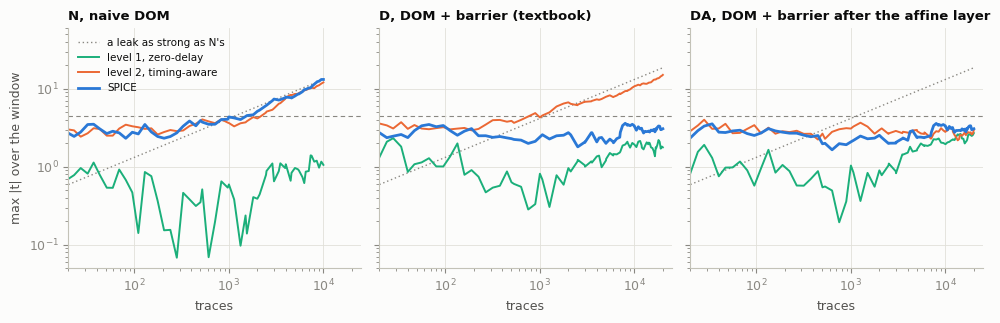

In [8]:
nbfigs.show(nbfigs.maxt_vs_traces())

The zero-delay model is not just unlucky here: it **cannot** see this leak. The value-model probing check (§3.3)
shows that every net's settled value, and every cell's settled input tuple, is independent of $x$
([`docs/reviews/sca-method.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/reviews/sca-method.md), check 1). With fresh masks in every row, the expected toggle count is therefore the
same for both classes, under any weighting. So the leak is not in *what* N computes but in *how* it gets there.

What makes the SPICE result trustworthy (details and re-runs in [`docs/reviews/`](https://github.com/Sarkar22/ascon-glitch-leakage/tree/main/docs/reviews)):
* **Where:** the leak sits in the evaluation, 0.6 to 1.3 ns after the capturing edge, with its peak at
  0.945 ns. The other parts of the cycle stay below 4.5: the clock edge (\|t\| 1.94), the flip-flops'
  clock-to-Q (0.87), the clock's falling edge (3.1) and the input edges (1.9). The fixed-minus-random mean current
  is a bump of up to 27 µA.
* **Replication:** each half of the data shows it at the same sample with the same sign. It also appears
  *without a fixed class*: an ANOVA of the supply current over $x$ in the random-vs-random campaign gives
  $F = 21.8$ at the same 0.945 ns.
* **Not numerics:** re-simulating 240 rows (600 in a second check) with a 1 ps (2 ps) step and much tighter
  tolerances reproduces the bump (27.4 against 27.7 µA; 31.73 against 31.69 µA), and the numerical error does not
  depend on the class.
* **Energy as well as timing:** on the total charge per cycle the fixed-vs-random \|t\| is only 3.23, but an ANOVA over
  $x$ on the same charge is significant. N's leak is concentrated in the timing of the evaluation; its total
  energy also depends on $x$, more weakly.

### 4.2 One input change, animated

What happens inside one clock cycle? The animation follows AND $t_1 = \overline{x_1}\,(x_2 \oplus x_1)$ along
share 0 of its output, in N (top) and DA (bottom), for one stimulus row. It uses the level-2 event model. Every
transition is drawn at its Liberty delay; glitch pulses are shaded.

![Glitch propagation in N and DA, one input change](media/glitch_N_vs_DA.gif)

* **In N**, $b^{(1)} = x_2^{(1)} \oplus x_1^{(1)}$ is computed *after* the input registers, so it arrives late
  and glitches. The cross-domain product $m_{01} = \overline{a^{(0)}}\, b^{(1)}$ then switches while it
  sees both shares of $x_1$. From there the glitch runs through three more XOR levels (the integration
  $p_{00} \oplus p_{01}$, the S-box XOR and the output layer) to the output register's D pin.
* **In DA**, $b^{(1)}$ comes straight from a register, so no cone of the AND holds a variable twice. The
  products can still glitch (here $p_{01}$, from the skew between $r_1$ and $m_{01}$), but those glitches end at
  the barrier flip-flops' D pins. In the next cycle the integration starts from registered values.

The next cell rebuilds the animation (live mode) or reads the cached events, and draws the last frame (Figure 4);
on Colab, where the image link above may not load, it also plays the animation. The row shown was chosen because
its glitch runs the whole path. Other rows differ, and the statistics are in §4.3. SPICE adds a second effect that one row cannot show: the cross-domain ANDs that leak first rarely glitch in
SPICE. Their leak comes mostly from *when* their single transition happens ([`docs/reviews/spice-circuit.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/reviews/spice-circuit.md), F2).

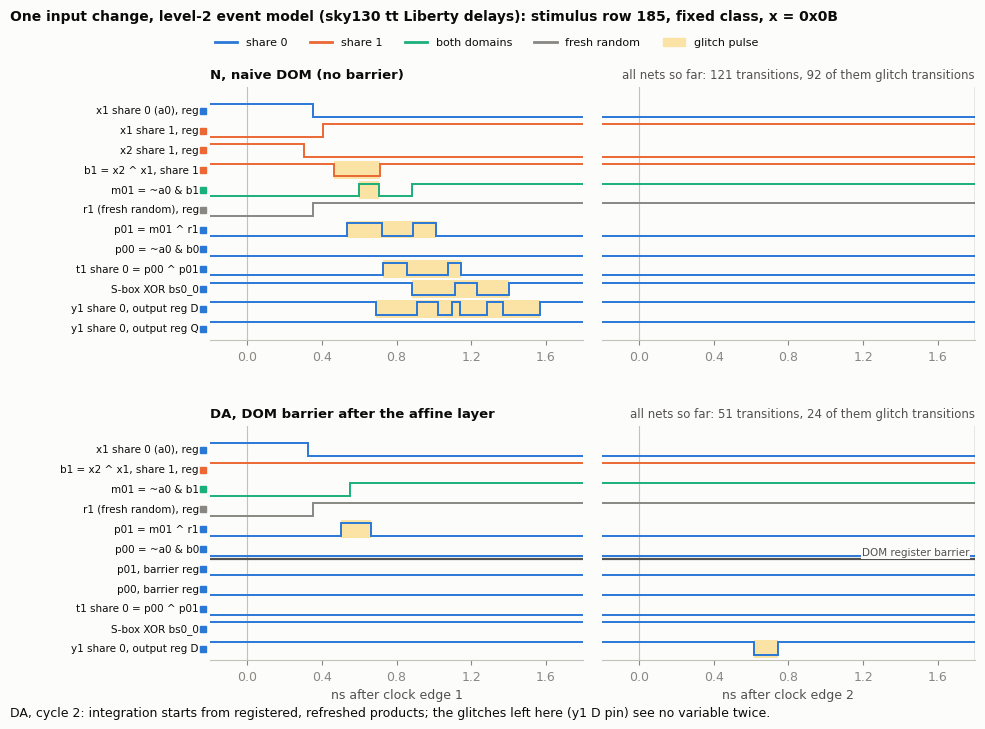

In [9]:
EV = nbanim.events(MODE)
GIF = os.path.join('media', 'glitch_N_vs_DA.gif')
if MODE == 'live' or not os.path.exists(GIF):
    nbanim.save_gif(EV, GIF)
if 'google.colab' in sys.modules:   # the image link above may not load
    from IPython.display import Image, display
    display(Image(filename=GIF))
nbfigs.show(nbanim.draw(EV, t_now=5.8))

### 4.3 Which nets carry N's leak

A second SPICE run on the first 1,998 traces saved every net's voltage. For each net it counts VDD/2
crossings in 20 ps bins and runs the same fixed-vs-random t-test on those counts. The re-run reproduces the
campaign's supply current with correlation 1.000000. **Figure 5:** 7 nets exceed 4.5:
m01_1, m10_1, ts1_1, m01_3, p01_3, m10_3, ts1_3. **All of them are flagged by glitch-extended probing.** The cross-domain
products (`m01`, `m10`) leak first, at 0.57–0.69 ns. Their integration nets (`ts`, `bs`) follow up to about 1 ns,
which is where the supply-current t peaks. Cross-domain nets that probing does *not* flag (the ANDs $t_0$ and
$t_2$, the same cell types) stay at \|t\| ≤ 3.3. On a permutation null over every net and bin, the maximum is about
4.2. Level 2 on 19,997 rows gives the same picture: 38 nets leak, and every one is flagged.

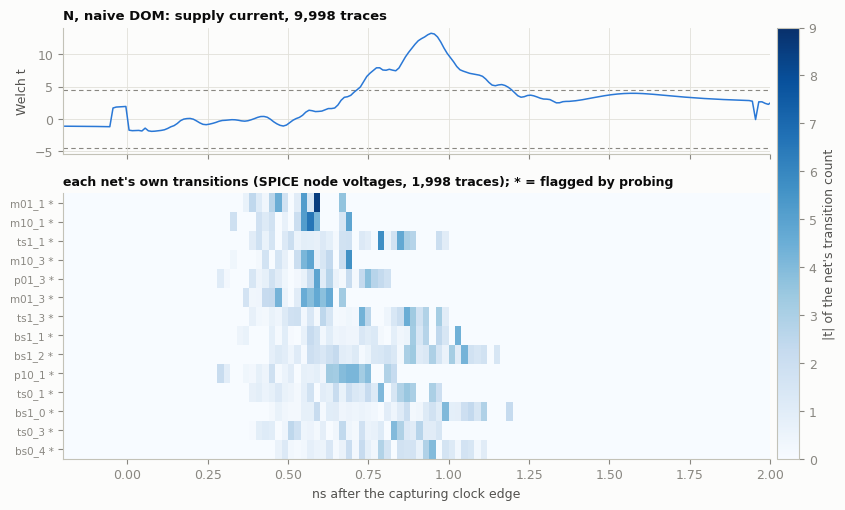

In [10]:
nbfigs.show(nbfigs.localization('N'))

**Two structural causes, two fixes.** The flagged nets of N fall into two groups, and the node data show both
([`docs/reviews/spice-circuit.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/reviews/spice-circuit.md), F6).
1. *ANDs whose inputs share a variable* through the input affine layer ($t_1$, $t_3$, $t_4$). Their cross-domain
   products see both shares of $x_1$, $x_3$ or $x_4$ before any register. A barrier after the products does
   not help, because the product itself already leaks. D keeps this cause; DA removes it.
2. *Integration without a barrier*, even for the ANDs with independent inputs ($t_0$, $t_2$; for example `ts0_0`).
   When $a^{(0)}$ switches, $p_{00} = \overline{a^{(0)}} b^{(0)}$ switches if $b^{(0)} = 1$, and
   $p_{01} = \overline{a^{(0)}} b^{(1)} \oplus r$ switches if $b^{(1)} = 1$. If both switch, their skew makes a
   glitch on $p_{00} \oplus p_{01}$. Both switching needs $b^{(0)} = b^{(1)} = 1$, which happens only when the
   unshared $b = 0$, so whether the XOR glitches depends on $b$. DOM's register barrier removes this cause.

### 4.4 Textbook DOM (D): a real net-level leak, not seen in the supply current

D has the register barrier that DOM prescribes, but it registers the partial products *after* Ascon's input affine
layer. The ANDs $t_1, t_3, t_4$ get inputs that share a variable, so their cross-domain products see both shares of
$x_1$, $x_3$ or $x_4$ before the barrier. Probing flags 12 nets. In SPICE, 5 of them switch in a
class-dependent way (m01_1, m10_1, p10_1, m01_3, m10_3; 997 traces, Figure 6). **But the supply current stays at max\|t\|
3.08 at 19,997 traces** (at most 3.62 at any checkpoint), while the timing-aware model (level 2) predicts
15.2 on the same rows (cap-weighted; 16.7 with the worst weighting). The pre-registered minimum for D was 10,000
traces; the run to 19,997 was exploratory, beyond it ([`docs/KILL_TEST.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/KILL_TEST.md), addendum). At this count TVLA would reach
4.5 on average for a leak a quarter as strong as N's. So the leak that level 2 predicts for D does not show in the
supply current at 19,997 noiseless traces: if it is there, it is smaller than that. This is not a proof that D is
secure. The glitch-extended probing model, which is conservative by design, still flags it.

A circuit-level reason why it is small: D's cross-domain nets glitch as often as N's (2.30 vs 2.29 pulses per row).
But in D each glitch ends at one flip-flop D pin. In N it travels through three more XOR levels: glitches are 28 % of
N's switching charge and 8.7 % of D's ([`docs/reviews/spice-circuit.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/reviews/spice-circuit.md), F5). Level 2 overstates D at 10 ps
resolution: in 100 ps bins it gives 2.71.

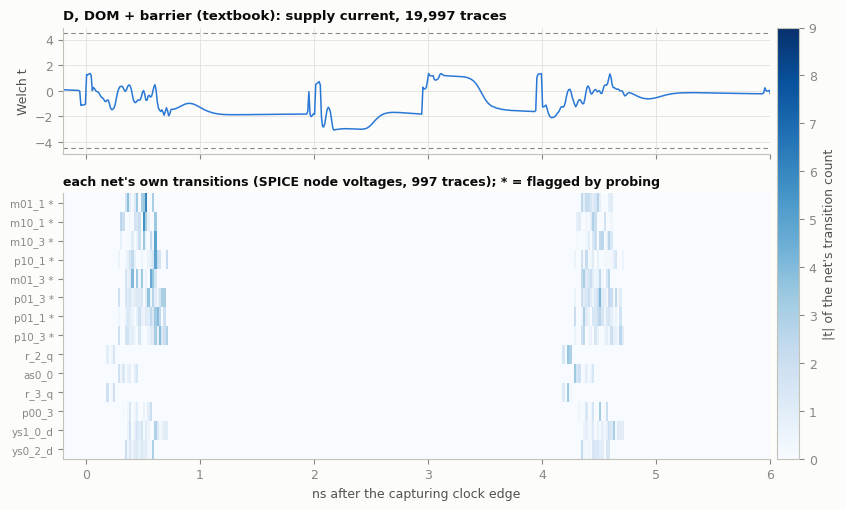

In [11]:
nbfigs.show(nbfigs.localization('D'))

### 4.5 The fix: DA

Moving the input affine layer in front of the input registers (DA) gives the ANDs independent inputs. The same
DOM barrier then does its job. In the probing check, DA has **0 insecure nets**. In SPICE, **max\|t\| is
3.08 at 19,997 traces** (at most 3.60 at any checkpoint; Figures 1 and 3), and level 2 agrees
(2.96, worst of three weightings). At this count TVLA would reach 4.5 on average for a leak of $\delta = 0.064$ standard deviations,
a quarter of N's $\delta_N = 0.265$. A leak of that size would be missed about half the time, and a
smaller one is not excluded. D and DA end at the same
max\|t\| at the same sample (2.175 ns, in the first cycle's clock-fall region), and their t-curves differ by at most
0.004 within 30 ps of it. The likely source is circuitry that D and DA share, driven by the same stimulus rows,
for example the registers of the input bits that the affine layer leaves unchanged; this was not checked at the net
level. If so, the two maxima are one observation, not two. The second-order
t is large (21.5), as expected for two-share masking: first-order masking protects the mean, not the
variance. §7 prices the fix.

### 4.6 How far can the cheap models be trusted?

The next table compares the three levels on the same rows. The charge-per-trace correlation measures how well a
model predicts *energy*. The level-2 lag is the time shift that best aligns its waveform with SPICE's.

In [12]:
nbfigs.show_md(nbfigs.model_table())

Campaign,Traces,SPICE max|t|,level 2 max|t| (cap-weighted),level 1 max|t| (cap-weighted),"charge per trace, corr. SPICE vs level 1 / level 2",level-2 lag (ps)
U_tvla,"1,998",37.4,37.3,27.01,0.98 / 0.89,+190
N_masksoff,998,27.5,26.8,19.16,0.98 / 0.85,+250
N_rvr,"9,998",1.9,3.1,0.15,0.87 / 0.73,+220
N_tvla,"9,998",13.2,12.1,1.06,0.88 / 0.77,+190
D_tvla,"19,997",3.1,15.2,1.78,0.97 / 0.87,+200
DA_tvla,"19,997",3.1,3.0,2.71,0.95 / 0.89,+200


* **Level 1 gets the energy right and the security wrong.** Its per-trace charge correlates with SPICE at
  0.87–0.98, better than level 2, yet it misses N's leak entirely (§4.1).
* **Level 2 flags N and names the right nets** (§4.3). **It does not reproduce the leak's waveform, sign or
  timing**, and its per-sample \|t\| is not a prediction of SPICE's: its 12.1 (cap-weighted) against SPICE's 13.2 is a
  coincidence. Figure 7 shows why. SPICE's t is a smooth positive hump; level 2's alternates in sign.
* **Level 2 and the pre-layout SPICE disagree by about 200 ps.** A large part of that comes from the SPICE cell
  netlists, which have no parasitics and switch faster than their Liberty characterization (clock-to-Q
  0.18–0.29 ns in SPICE against 0.31–0.41 ns in Liberty). Neither model is silicon.
* **Level 2 is pessimistic for D** at 10 ps resolution (§4.4).

So the probing check and level 2 are good *screening* tools, and SPICE remains the reference.

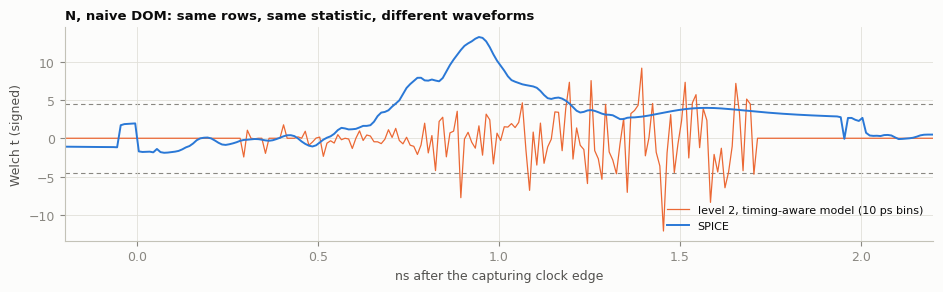

In [13]:
nbfigs.show(nbfigs.model_vs_spice('N'))

### 4.7 Robustness: added noise and limited bandwidth

A real measurement adds noise and low-pass filters the current. **Figure 8** adds white Gaussian noise to the SPICE
traces, at 0.5, 1 and 2 times the largest per-sample standard deviation of the noiseless traces (1x = 341.3 µA
for N). N stays detectable within 9,998 traces at 0.5x (above 4.5 from 2,470 on) and at 1x (from
6,273 on), but not at 2x (3.85). DA ends below 4.5 at every noise level, and never stays above it:
at 1x it touches 4.93 at an early checkpoint (above 4.5 first at 34 traces; D reaches
6.0) and falls back. These are the small-sample false alarms that [`docs/KILL_TEST.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/KILL_TEST.md) explains. Bandwidth, on the
noiseless N traces: 12.7 in 100 ps bins, 10.6 in 1 ns bins, 9.5 after a 1 GHz first-order low-pass and 5.5 after
250 MHz ([`docs/reviews/spice-circuit.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/reviews/spice-circuit.md), check 19). So the leak does not depend on a 10 ps probe.

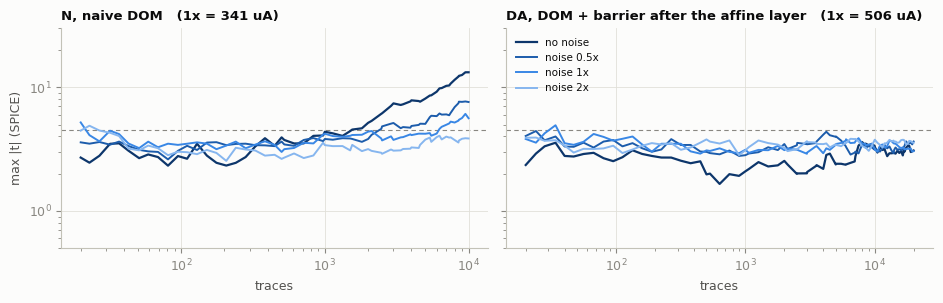

In [14]:
nbfigs.show(nbfigs.noise())

### 4.8 Explore the TVLA yourself

The cached data set holds, for the four fixed-vs-random SPICE campaigns, Welch's t at 25 trace counts and the
per-class statistics (`data/tvla_t_checkpoints_*.csv`, `data/class_stats_*.csv`). That is enough to redo the test
with any amount of added noise. With
ipywidgets installed, move the sliders to choose the variant, the number of traces (checkpoint) and the noise (in
units of the largest noiseless per-sample standard deviation). Without it, the default views below are shown.
The noise is folded in statistically (described in `nbexplorer.py`). The cell also compares five noise draws
for N at 1x with the kill test's exact trace-by-trace result (5.6).

**Figure 9.** Default views: N without noise, N at 1x noise, and DA without noise.

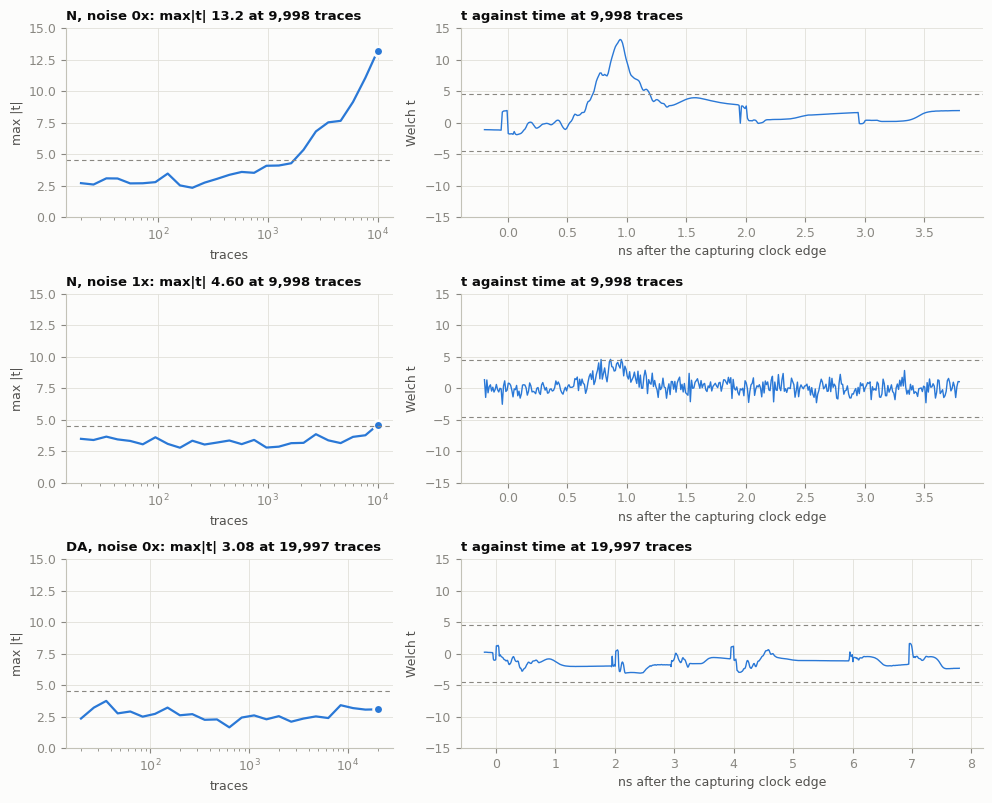

N at 1x noise: exact 5.62; from the cached statistics 4.60, 5.43, 6.25, 5.39, 5.08
ipywidgets is not installed: the static views above are all.


In [15]:
nbfigs.show(nbexplorer.static_panel())
exact, approx = nbexplorer.check_against_exact('N_tvla', 1.0)
print('N at 1x noise: exact %.2f; from the cached statistics %s'
      % (exact, ', '.join('%.2f' % a for a in approx)))
if not nbexplorer.interactive_panel():
    print('ipywidgets is not installed: the static views above are all.')

## 5. Key recovery: what does an attacker get?

TVLA says whether the current depends on the data; it does not say what an attacker can do with it (§8). This
section runs a profiled attack on the same SPICE traces. It is **post hoc**: it was designed after the kill test,
to answer the question that K1's CPA could not settle (§3.6), and it is not a registered criterion.

**Attack model.** One S-box column in Ascon's initialization: $x_0$ is an IV bit (known), $x_1, x_2$ are two key
bits (secret), and $x_3, x_4$ are two nonce bits (known, varying). Each (IV, key) pair is one scenario with four key
guesses. The attacker first *profiles* an identical device: from traces with known inputs it learns the mean trace
of each of the 32 inputs and the noise covariance (a *template*). It then *attacks* other traces, with known nonces
and an unknown key, and ranks the four guesses by how well each guess's predicted inputs explain those traces. The
traces are the random-class rows of the TVLA campaigns; the fixed 0x0B rows are never used. Profiling and attack
rows come from disjoint 50-row blocks with 3 unused guard rows in between, so no trace of one set depends on an
input of the other. Every number is averaged over 10 random splits and 50 random orderings of the
attack traces ([`analysis/key_recovery.py`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/analysis/key_recovery.py)).

**Metric.** The key rank is the number of wrong guesses that score above the correct one. Its mean is the
*guessing entropy* (GE): 0 means the key is found, 1.5 is random guessing among four. The *success rate* (SR) is
P(rank 0); random is 0.25.

**Distinguishers.**
* The **Gaussian template** is the primary one. It was made primary after a review
  ([`docs/reviews/stage2-key-recovery.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/reviews/stage2-key-recovery.md), B2), for the structural reason given in the third point; on D and DA both
  distinguishers are at chance at first order, so no verdict there depends on that choice. Its points of interest
  (POIs) are the samples where the 32 input means differ most (ANOVA F); their number is chosen by cross-validation on
  the profiling rows.
* The same template with **per-key-bit POIs**: the top-F sample plus, for each key bit, the sample where that bit's
  effect *inside every combination of the other four bits* is largest. It was added post hoc, after a review found
  that the default POIs miss one of N's key bits ([`docs/reviews/stage2-key-recovery.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/reviews/stage2-key-recovery.md), B1).
* A **correlation** distinguisher is shown as secondary only. It centres the traces over the attack set, and that
  removes exactly the level shift between keys that a key bit's main effect produces.

**Null.** The same pipeline with the profiling labels permuted gives the null distribution (20 draws per
configuration without added noise). Without added noise, the standard deviation of the null's final GE is
0.07-0.10 for the default template and 0.07-0.11 for the per-key-bit template on U, N, D and DA
(TVLA campaigns), and 0.17 for U on the K1 CPA traces, which have only four keys. A result is better than
chance when its GE falls below the null draws: $p$ = (1 + draws at or below the result) / (draws + 1), so with 20
draws $p$ = 0.048 means below every draw.

**Figure 10.** GE of the Gaussian template against the number of attack traces per key, from
`data/key_recovery__summary.json`. Gray: the null (mean ± 2 SD). The table below the figure lists the final values. Its
null column is the default template's; the per-key-bit template has its own null (N: 1.48 ± 0.09).

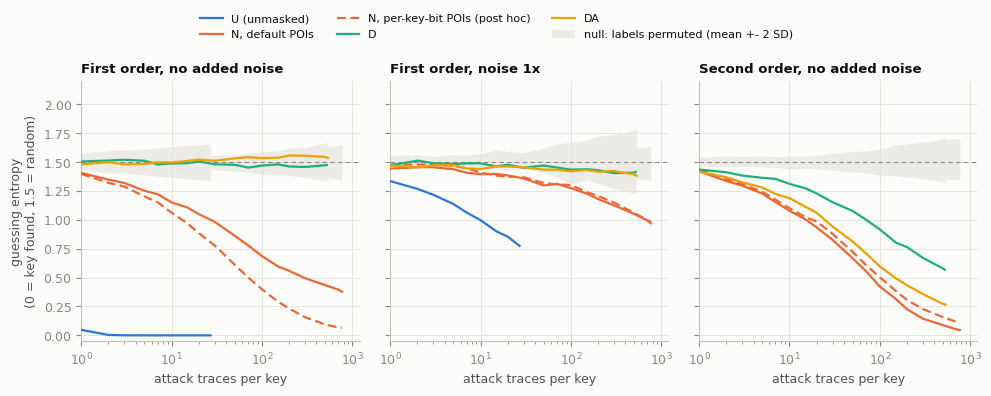

"Variant, order",attack traces per key,"template, default POIs: GE (SR)","template, per-key-bit POIs (post hoc): GE (SR)","null GE of the default template, mean +- SD",p vs null (default POIs),correlation GE (secondary)
"U, 1st",27,0.00 (1.00),0.00 (1.00),1.50 +- 0.08 (20 draws),0.048,0.00
"U on the K1 CPA traces, 1st","1,998",0.00 (1.00),0.00 (1.00),1.46 +- 0.17 (20 draws),0.048,0.00
"N, 1st",765,0.38 (0.62),0.07 (0.93),1.49 +- 0.08 (20 draws),0.048,1.17
"D, 1st",521,1.48 (0.25),1.52 (0.22),1.51 +- 0.07 (20 draws),0.286,1.52
"DA, 1st",533,1.54 (0.23),1.66 (0.18),1.50 +- 0.09 (20 draws),0.667,1.52
"N, 2nd",765,0.05 (0.96),0.11 (0.91),1.53 +- 0.09 (20 draws),0.048,0.33
"D, 2nd",521,0.57 (0.61),0.58 (0.61),1.50 +- 0.07 (20 draws),0.048,0.96
"DA, 2nd",533,0.27 (0.78),0.35 (0.73),1.52 +- 0.10 (20 draws),0.048,0.99


In [16]:
nbfigs.show(nbfigs.key_recovery())
nbfigs.show_md(nbfigs.key_recovery_table())

**N gives up both key bits at first order.** With the default POIs the template finds key bit $x_1$ (the top guess
has the right $x_1$ with probability 1.00) but not $x_2$ (0.63): GE 0.38, SR 0.62 at 765
attack traces per key. $x_2$ has no main effect at the leak's peak, but it does leak at first order through its
interactions with the other bits, later in the evaluation: the per-key-bit POI for $x_2$ falls at 1.275-1.295 ns
after the edge, against the main peak at 0.945 ns. With that POI the template reaches **GE 0.07, SR
0.93** (the right $x_2$ with probability 0.93; null 1.48 ± 0.09,
$p$ = 0.048). On the N_tvla campaign alone, 231 traces per key, the per-key-bit POIs give GE
0.43 (default POIs 0.64). With
added noise of 1x the template's GE rises to 0.97 (default) and 0.99 (per-key-bit POIs) at
the same trace count. The correlation distinguisher stays at GE 1.17 on noiseless N: it is blind to the main
effect that carries $x_1$.

**D and DA: no first-order key recovery, and what that rules out.** D gives GE 1.48 at 521 attack traces per key (null
1.51 ± 0.07, $p$ = 0.29) and DA 1.54 at 533 (null 1.50 ± 0.09,
$p$ = 0.67). On its own, "no key recovery" says little. So N's first-order leak, scaled by a factor $\alpha$,
was added to the real D and DA traces at one sample, and the unchanged attack was run again (Figure 11; $\alpha = 1$
is N's own per-sample effect). At this data volume the template detects the injected leak from $\alpha$ =
0.35 on D (GE 1.22; not at 0.25, GE 1.55) and from $\alpha$ = 0.5 on DA
(GE 1.03; not at 0.35, GE 1.38). Detected means a GE below all 20 null draws. TVLA on
the same campaigns already reaches 4.5 for a leak a quarter as strong as N's (§4.5).
So for D and DA the key recovery is a consistency check: it adds no sensitivity beyond the TVLA. The correlation
distinguisher misses the injected leak even at N's full strength (GE 1.47 on DA, 1.49 on D),
which is why it is not the primary distinguisher.

**Figure 11.** D and DA: GE at the last checkpoint after adding $\alpha$ times N's first-order leak to the real
traces ($\alpha$ = 0: the real traces). The dotted line marks the leak size at which TVLA on the same campaign reaches
4.5 on average.

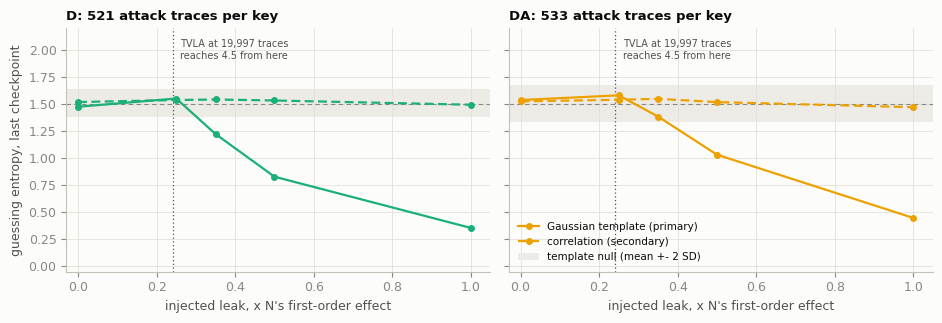

In [17]:
nbfigs.show(nbfigs.key_recovery_injection())

**Second order.** First-order masking does not protect the variance, so a univariate second-order template is
expected to work on the masked variants, and it partly does: on DA it reaches GE 0.27, SR 0.78 at
533 traces per key ($p$ = 0.048), and on D GE 0.57, SR 0.61 at 521 ($p$ = 0.048). For N the second-order result (GE 0.05) is
not independent evidence: the centred square at a sample with a first-order mean shift carries that shift.

**K1, answered post hoc.** Templates from U's TVLA campaign recover U's key from the K1 CPA traces without added
noise (SR ≥ 0.9 from 2 traces per key). This answers the question K1 was meant to settle, whether the
traces carry exploitable key information, but **K1 stays failed as registered**. With added noise the outcome
depends on the distinguisher. At 0.5x the template gives GE 1.25 and the correlation
0.50 (SR 0.75); at 1x, 1.50 and 0.00
(SR 1.00). All 1,998 traces of a key are used there, so each of the four keys is one
deterministic outcome, and these numbers are coarse. The CPA campaigns keep the IV and key bits fixed from row to
row, so their traces draw 18-27 % less charge than the U_tvla templates predict. The template, which
compares absolute levels, suffers from that mismatch between campaigns; the centred correlation does not.

**What the attack assumes.** A profiling device identical to the target (here: the same simulation), noiseless
traces unless noise is added, known nonces, and a two-bit key with four guesses. It is a lower bound on what an
attacker gets from N, not a certificate for D or DA.

## 6. Layout and post-layout: does the leak survive place and route?

§4 simulated the generator's netlists with an estimated wire capacitance and the stock cell netlists, which carry no
parasitics (§8). To see whether its verdicts hold after physical design, N, DA and U were taken through OpenLane v1 on
`sky130_fd_sc_hd`, and N and DA were simulated again from their extracted layouts.

**Keeping the generator's netlist.** The flow must not change the circuit under test:
* Yosys only elaborates the structural netlist; there is no technology mapping.
* All resizer and buffering steps are off.
* The flow adds only the clock tree, tap, decap and fill cells.

[`layout/summarize.py`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/layout/summarize.py) checks the result. Every logic instance of the generator's netlist is in the final layout with
the same cell type and the same net on every pin, except the flip-flops' clock pins, which now hang on the clock
tree's leaf nets (25 in N, 55 in DA). The table is read from `data/layout__summary.json`; its
capacitance row comes from `data/pex__summary_postlayout.json`. §6.3 shows that the same LVS and DRC checks fail on
deliberately broken inputs.

In [18]:
nbfigs.show_md(nbfigs.layout_table())

,N,DA,U
die (um),61.3 x 72.0,74.5 x 85.2,40.1 x 50.8
core area (um^2),"2,455","3,942",788
placement utilisation,44.2 %,43.4 %,48.4 %
"logic cells: generator / final, types and pins unchanged","88 / 88, yes","118 / 118, yes","27 / 27, yes"
clock-tree buffers added,3 x clkbuf_16,5 x clkbuf_16,3 x clkbuf_16
"other cells added (buffers, resizing, diodes)",0,0,0
tap / decap / fill cells,30 / 148 / 54,50 / 224 / 72,12 / 52 / 14
"setup / hold worst slack at 4 ns, tt (ns)",1.78 / 0.25,2.05 / 0.13,2.12 / 0.29
DRC: router / Magic / KLayout,0 / 0 / 0,0 / 0 / 0,0 / 0 / 0
LVS (netgen),clean,clean,clean


**Figure 12.** Top: the N and DA layouts, rendered by KLayout with all drawn layers in the PDK colours. Each image is
scaled to its own die; the titles give the sizes. Bottom: the placements. Each logic cell is coloured by the share
domain of the net it drives, the cross-domain ANDs are black, and a hatched cell drives a net that glitch-extended
probing flags. In N the cross-domain ANDs sit between the share-0 and share-1 halves. Small copies of
`results/layout/*.png` are in `media/`.

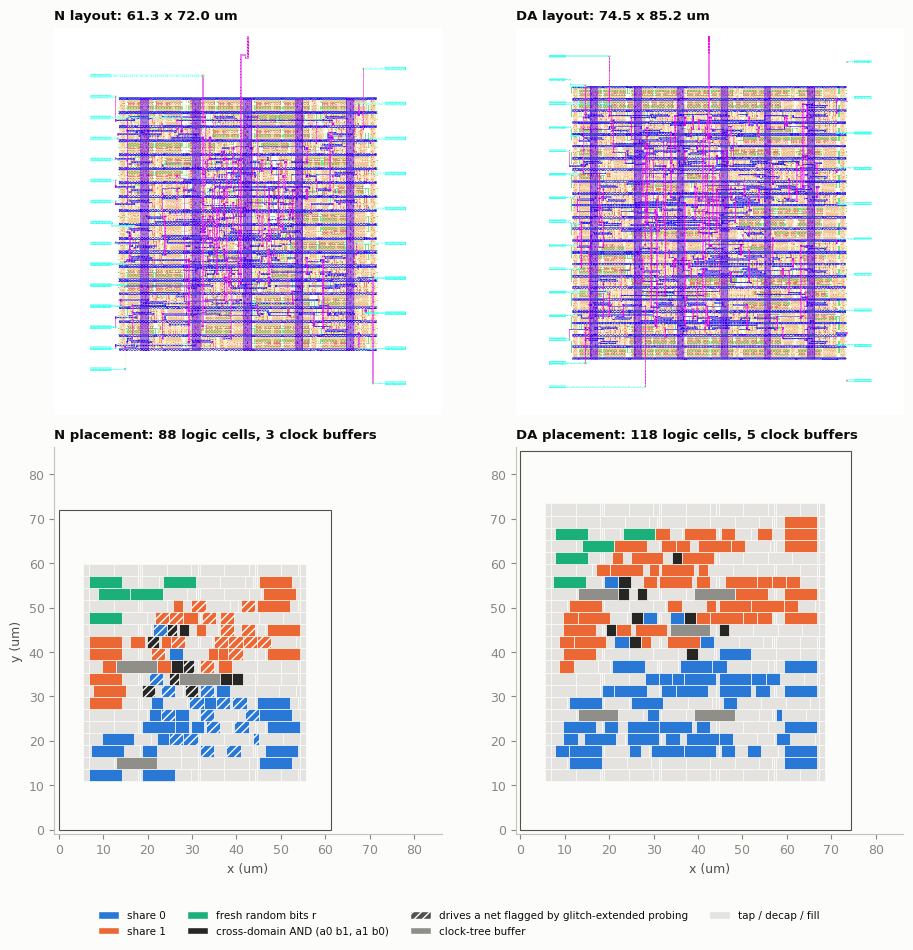

In [19]:
nbfigs.show(nbfigs.layout_figure())

### 6.1 The post-layout SPICE model

Magic extracts every transistor with its drawn W, L and diffusion geometry, every capacitance to substrate and every
coupling capacitance between nets. The campaigns' extraction has no resistance; a post-hoc RC bracket of N (§6.3)
delays its evaluation by about 61 ps and changes little else. The extracted netlist replaces the
generator's `dut.sp` in the unchanged SPICE runner. Three things change against §4's model:
* **Capacitance.** The routed wiring alone (OpenRCX) totals 179 fF on N's logic nets, the same as the
  pre-layout estimate (178 fF). With the cells' own pin geometry, which the stock cell netlists lack,
  Magic extracts 392 fF (2.2x). The layouts also add coupling between the share
  domains: 7.0 fF between N's share-0 and share-1 nets, 7.8 fF in DA.
* **Timing.** A node run of 38 cycles of N measures the median flip-flop clock-to-Q at 0.56 ns after the
  ideal clock edge, against 0.20 ns before layout. This includes the clock tree's insertion delay of about
  0.33 ns (from the flow's clock-tree timing, quoted in [`layout/README.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/layout/README.md)). The median last logic transition moves
  from 1.06 to 1.83 ns (at most
  2.01), still 2 ns before the next edge.
* **The clock tree.** Its buffers (N 3, DA 5 × `clkbuf_16`) and the flip-flops' clock pins
  now draw from the measured supply. This current does not depend on the data.

**Checks.** Every registered output of the post-layout campaigns matches the S-box, and matches the pre-layout output
of the same row: 0 mismatches in 5,000 rows of N and 10,000 rows of DA. The campaigns use ngspice's KLU
solver. On the same netlists and 120 rows it agrees with the default solver used before layout: the charge differs
by at most 1.5e-4 (relative), and the data-dependent parts correlate at 0.9999997.

### 6.2 Post-layout TVLA

The criteria were registered in [`docs/POSTLAYOUT.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/POSTLAYOUT.md) while the N campaign was running:
* **PL1:** N leaks after layout.
* **PL2:** DA does not.
* **PL3** (informational): where the t-peaks sit, and the smallest leak TVLA could detect in DA.

The trace counts were fixed: the first 5,000 rows for N and the first 10,000 rows for DA, of the stimulus that §4 used.
Before the registration the progress view had printed N's max\|t\| three times (2.55, 3.00 and 4.30 at 373, 748 and
1,498 traces). These looks are disclosed there, and neither trace count depended on them. The test is the kill
test's own code path. As a check, the same analysis run on the pre-layout campaigns reproduces their results exactly.
The table is read from `data/pex__summary_postlayout.json`.

In [20]:
nbfigs.show_md(nbfigs.postlayout_table())

Id,Registered criterion,Traces,Post-layout (extracted netlist),"Pre-layout, same rows",Result
PL1,"N: max|t| > 4.5, the leak survives place and route","4,998","8.19 at 1.655 ns, above 4.5 from 1,902 on","8.07 at 0.945 ns, above 4.5 from 1,657 on",pass
PL2,"DA: max|t| < 4.5, the fix survives place and route (measured: no detection at 9,997 traces)","9,997","3.36, never above 4.5 (at most 3.62 at any checkpoint)",3.35,pass
PL3,Where the t-peaks sit; the smallest leak TVLA could detect in DA (informational),-,"N: all 39 samples above 4.5 in 1.415-1.795 ns (evaluation part; clock fall 1.13, input edges 1.13). DA: no sample above 4.5. TVLA at 9,997 traces reaches 4.5 on average for 0.39 x N's post-layout effect",N: 0.765-1.115 ns,informational


**Figure 13.** Signed Welch t against time after layout (blue) and before layout on the same rows (gray), from
`data/pex__tcurve_*.csv`. Time counts from the ideal clock edge at the block's CLK pin.

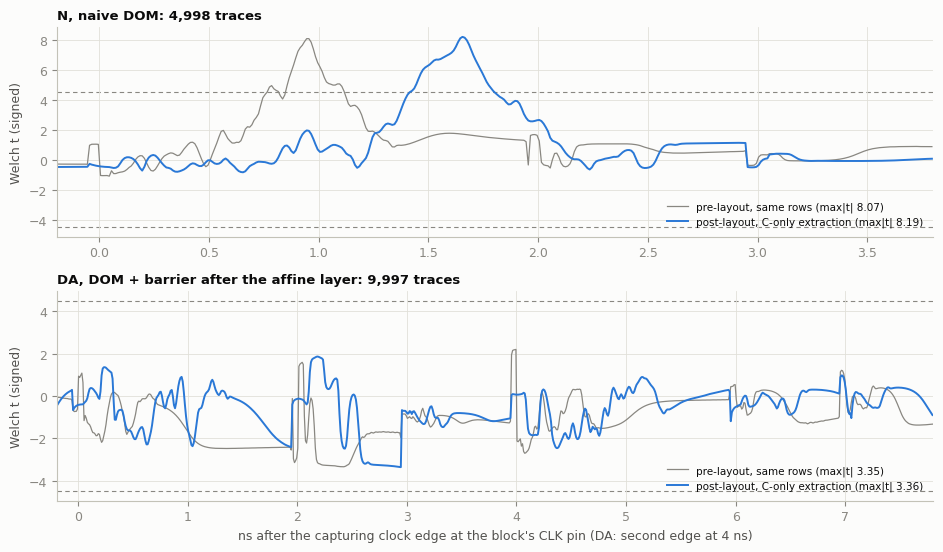

In [21]:
nbfigs.show(nbfigs.postlayout_tcurves())

* **N's leak survives place and route under C-only extraction at tt.** On the same rows it is as strong as before
  layout: 8.19 against 8.07 at 4,998 traces. It crosses 4.5 at 1,902 against
  1,657 traces.
* **The leak keeps its shape and moves later.** The t-curve is shifted 0.69 ns: the two curves correlate
  at 0.88 at that shift and at 0.16 without it. The shift fits the slower clock-to-Q and
  evaluation of §6.1.
* **It stays in the evaluation.** All 39 samples above 4.5 lie in 1.415-1.795 ns, inside the registered
  evaluation part. The clock-fall and input-edge parts stay at or below 1.13. When the parts were registered,
  an interim look had already shown N's peak at 1.645 ns ([`docs/reviews/stage3-layout-pex.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/reviews/stage3-layout-pex.md), N3); the node timing
  alone (last transition up to 2.01 ns, §6.1) justifies the 2.1 ns boundary, and PL3 is informational.
* **It is still a leak of timing, not of total charge.** On the charge per cycle \|t\| is 2.34 (2.48
  before layout). In 100 ps bins the leak stays at 7.97.
* **DA shows no first-order leak after layout** at 9,997 traces: 3.36, at most 3.62 at any
  checkpoint (3.35 before layout on the same rows).
* **How small a leak DA's result could miss.** At this count TVLA reaches 4.5 on average for a leak
  0.39 times as strong as N's post-layout one, so a leak of that size would be missed about half the
  time. The bound is weaker than §4.5's 0.24 at 19,997 traces for two reasons. The registered
  post-layout campaign has half the traces, which alone gives 0.34. And N's effect measured on
  its first 4,998 rows ($\delta$ = 0.232) is smaller than on all 9,998 ($\delta_N$ = 0.265).
* **DA's second order grows after layout,** from 15.0 to 22.3. This is expected for two-share
  masking and is informational only.
* **Added noise.** With noise added in the same way as in §4.7, N stays above 4.5 from 2,500 traces
  at 0.5x, as it does before layout. At 1x neither netlist stays above 4.5 within 4,998 traces: both end below it
  (3.84 after layout). The only crossings are small-sample false alarms at 20-105 traces (§4.7); the
  kill test needed 6,273 traces for N at 1x, so this count is too short to say more.

**Figure 14.** max\|t\| against the number of traces, after layout (blue) and before layout on the same rows (gray).
The dotted line is the growth that a leak as strong as N's post-layout one would follow.

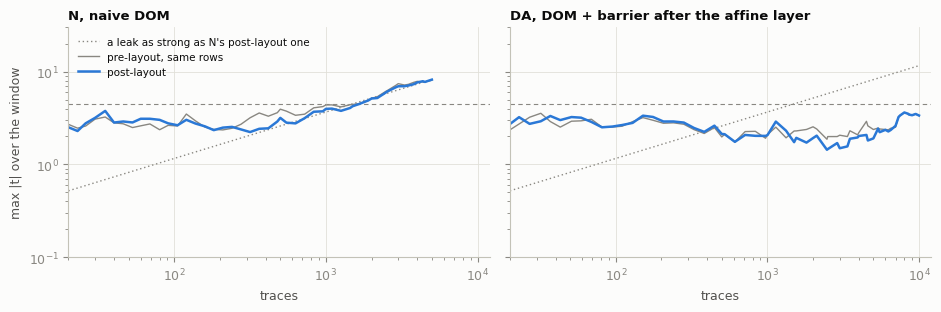

In [22]:
nbfigs.show(nbfigs.postlayout_maxt())

### 6.3 Post-hoc checks: do the sign-off checks bite, and what does resistance change?

These checks were run after the post-layout campaigns. They are not part of the registration in [`docs/POSTLAYOUT.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/POSTLAYOUT.md),
and no criterion depends on them (details in [`layout/README.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/layout/README.md)).

**Negative controls of the sign-off.** A DRC count of 0 and an LVS match mean something only if the same checks fail
on a broken input. Magic re-extracts each layout's netlist from its final GDS with OpenLane's sign-off commands, and
netgen compares it with OpenLane's final netlist and with three edits of that netlist. For DRC, a copy of N's GDS gets
two small defects inside the cell rows, and Magic (OpenLane's sign-off commands) and KLayout (the PDK's deck) check
both files. The share swap matters most: it changes one pin and no device or net count, and LVS still fails. So the
LVS match pins down the share-domain wiring that the leakage argument rests on. The table is read from
`data/layout__negative_controls.json`.

In [23]:
nbfigs.show_md(nbfigs.controls_table())

Check and input,Expected,N,DA
LVS: OpenLane's final netlist (the one its LVS step read),match,"match (96 / 96 devices, 109 / 109 nets)","match (128 / 128 devices, 141 / 141 nets)"
"LVS: one cross-domain AND input moved from its share-0 net to the share-1 net (N: g_m01_0.A_N, as0_0 -> as1_0)",mismatch,"mismatch, device and net counts unchanged","mismatch, device and net counts unchanged"
LVS: the first and2_1 made an or2_1 (same pins),mismatch,mismatch,mismatch
LVS: the first flip-flop deleted,mismatch,mismatch,mismatch
"DRC, Magic / KLayout: the final GDS",0 / 0,0 / 0,"not repeated (sign-off: 0, §6)"
"DRC, Magic / KLayout: a copy with a 0.07 um met1 gap (m1.2: 0.14 um) and a via1 with 0.03 um of met1 enclosure (via.4a: 0.055 um)","both defects, nothing else","Magic 10 markers, all on the two defects; KLayout 3 markers, all on the two defects","not repeated (sign-off: 0, §6)"


**Resistance, bracketed on 120 rows of N (a sanity check, not a TVLA).** Magic `extresist` adds 4,427
resistors (median 103 Ω, at most 511 Ω) on 603 signal nets, through the routing, vias,
contacts and the cells' own poly and li1. The supply rails stay ideal, as in the testbench, and the capacitance is the
C-only extraction's. Both netlists ran on the first 120 rows of the stimulus with the same runner and solver;
the C-only run matches the N_pex campaign's first rows within 0.9 µA per bin
(`data/pex__rc_check.json`). RC against C-only:
* **Function:** 0 mismatches against the S-box in either run, and the two runs' outputs are identical
  bit for bit.
* **Charge per window:** -0.24 % on average (at most 1.1 % in any row); the
  data-dependent parts correlate at 0.9998.
* **Supply current:** RC is 20 ps later. After that shift the data-dependent parts correlate at
  0.98 (0.94 without it), and the fixed-minus-random mean current, the numerator of the
  t-test on these rows, at 0.98 (0.95).
* **Timing** (node runs, 38 cycles): flip-flop clock-to-Q +25 ps on average (23-27
  ps). The last logic transition comes 61 ps later (median; 22-74 ps), at 1.89
  instead of 1.83 ns (at most 2.08 ns). Logic-net transitions, glitches included:
  2,057 against 2,065.

So resistance moves N's evaluation by tens of picoseconds, against the 0.69 ns by which place and route
moved its leak, and leaves the charge and the data-dependent current nearly unchanged. 120 rows cannot re-test
the verdicts; that would take an RC campaign, and the power grid's resistance is still left out.

**What the post-layout model leaves out** ([`layout/README.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/layout/README.md), [`docs/POSTLAYOUT.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/POSTLAYOUT.md)):
* resistance: the campaigns' extraction is capacitance only. The RC bracket of §6.3 adds wire, via and in-cell
  resistance on 120 rows of N, but not the power grid's;
* corners: tt at 27 °C only;
* placement: one layout per variant, from a single placement seed;
* sources: an ideal 1.8 V supply at the block's power pins, and ideal clock and input sources at its pins. There is no
  package and no on-chip decoupling effect;
* the layouts are blocks, not a chip;
* D was not laid out, and U was laid out but not simulated.

The claim these results support is: *under transistor-level simulation of the extracted, capacitance-only layouts at
sky130 tt, N's first-order leak survives place and route, and DA shows no first-order leak within 9,997 traces.*

## 7. Cost of the fix

The cost of each variant **before layout**, from the netlists, the Liberty file and the SPICE supply charge
([`analysis/cost_table.py`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/analysis/cost_table.py); every column with its definition in [`results/cost/cost.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/results/cost/cost.md)). The table comes first, then
**Figure 15**: cell area, energy per S-box evaluation (SPICE supply charge plus the estimated charge of the flip-flops'
clock pins) and latency in time, per variant. A second table gives N and DA **after layout** (§6).

Variant,cells,flip-flops,cell area (um^2),"cell area (GE, nand2_1)",area vs N,latency (cycles),min. clock period (ps),latency (ns),latency vs N,fresh random bits,"energy per evaluation, SPICE (fJ)",SPICE energy vs N,incl. CLK pins (fJ),total vs N (incl. CLK pins)
U,27,10,337.8,90,0.33,1,1417,1.42,0.74,0,525,0.31,583,0.32
N,88,25,1009.7,269,1.00,1,1917,1.92,1.00,5,1700,1.00,1846,1.00
D,118,55,1610.3,429,1.59,2,1230,2.46,1.28,5,2435,1.43,2755,1.49
DA,118,55,1610.3,429,1.59,2,1085,2.17,1.13,5,2372,1.39,2691,1.46


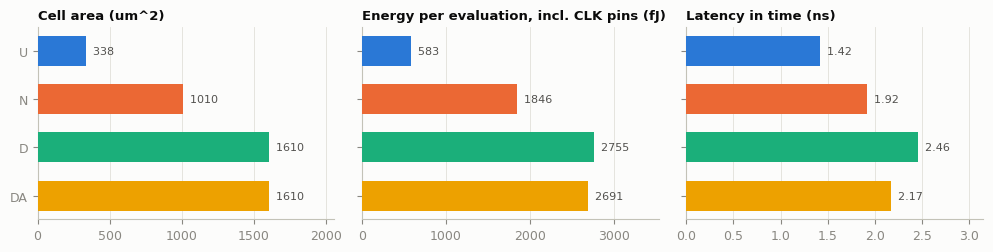

In [24]:
COST = nbfigs.cost_table()
if COST:
    nbfigs.show_md(COST)
    nbfigs.show(nbfigs.cost_figure())
else:
    print('cost table not written yet (results/cost/cost.csv)')

**After layout, N and DA.** This table gives the area after place and route (`data/layout__summary.json`) and the
energy per evaluation on the same rows before and after layout (`data/pex__summary_postlayout.json`). Both energies
use the definition of the table above. The post-layout energy also contains the clock tree, the clock pins and the
cells' own parasitics, which the pre-layout supply current leaves out, so the two energy rows are not
interchangeable.

In [25]:
nbfigs.show_md(nbfigs.postlayout_cost_table())

,N,DA,DA vs N
"core area after place and route, 40 % core-utilisation target, FP_CORE_UTIL (um^2)","2,455","3,942",1.61
die area after place and route (um^2),"4,412","6,347",1.44
"energy per evaluation, pre-layout SPICE, same rows (fJ)","1,709","2,374",1.39
"energy per evaluation, post-layout SPICE, incl. clock tree and CLK pins (fJ)","4,020","6,427",1.60


* **Area.** D and DA have the same 118 cells. The 30 extra flip-flops of the barrier make them
  59 % larger than N (1610 against 1010 µm² of cell area, without
  placement utilization or a clock tree). In gate equivalents (GE; one `sky130_fd_sc_hd__nand2_1` is 3.7536 µm²),
  the unit in which ASIC area is usually compared across processes, that is 90 GE for U, 269 GE for N
  and 429 GE for D and DA. After place and route with a 40 % core-utilisation target
  (`FP_CORE_UTIL`), DA's core is 3,942 µm² against N's 2,455 µm² (+61 %), and
  its die is +44 %.
* **Energy.** In SPICE, DA draws 2372 fJ per evaluation against N's 1700 fJ
  (+39 %). With the flip-flops' clock-pin charge, which the simulated current leaves out
  (ideal clock), it is +46 %. These are pipelined figures: a new input enters every cycle, so the
  charge per evaluation is the charge per cycle. A round-based core that cannot interleave two states needs two
  cycles per round with DA and pays about one more cycle of clock and register overhead. The charge is averaged
  over rows whose neighbours are random inputs too. Over all random rows of U's TVLA campaign it is 3.3 %
  lower, because a neighbouring fixed input (0x0B) changes the charge.
* **Energy after layout.** The simulated current now carries the clock tree (DA 5 buffers, N 3),
  the clock pins and the cells' own parasitics. On the same rows DA draws 6,427 fJ per evaluation against N's
  4,020 fJ: +60 %, against +39 % before layout.
* **Latency.** Two cycles instead of one, but a shorter cycle, because the barrier cuts the logic depth. In time, DA's
  latency is 2.17 ns against N's 1.92 ns (+13 %; D
  +28 %), not twice as long. DA's affine XORs add 141 ps in front of the input
  registers; in a round-based core they merge into the previous round's linear layer.
* **Randomness.** N, D and DA all use 5 fresh random bits per S-box evaluation. The fix
  costs no extra randomness.
* **What the cost buys** (§4, §5): N leaks at first order and gives up its key (with the post hoc per-key-bit points
  of interest); DA shows no first-order leak at 19,997 traces and no first-order key recovery, down to a leak
  half as strong as N's (§5). TVLA on the same traces is more sensitive: it reaches 4.5 on average for a leak a quarter as strong
  (§4.5).
  After place and route N still leaks, and DA still shows no first-order leak at 9,997 traces (§6).

## 8. Limitations

* **Simulation, not silicon.** The claim these results support is: *under transistor-level simulation of the
  pre-layout netlist on sky130 `tt`, N leaks at first order within 1,550 traces, and DA shows no first-order leak
  within 19,997 traces. After place and route, with capacitance-only extraction, N's leak survives (above 4.5 from
  1,902 traces), and DA shows no first-order leak within 9,997 traces (§6).* It is not a measured result.
* **Pre-layout parasitics.** Wire capacitance is an estimate (1 fF plus 0.5 fF per fanout pin). The stock
  `sky130_fd_sc_hd` SPICE cells carry no diffusion or junction capacitance (every FET has ad = as = pd = ps = 0)
  and no intra-cell wiring, so they switch faster than their Liberty data. N's leak survives both brackets that
  were tried on the same rows. With wire capacitance ×4, max\|t\| is 7.20 against 9.20 at 5,998 traces, and the peak
  moves from 0.945 to 1.385 ns. With diffusion capacitance added, it is 4.78 against 5.17 at 1,998 traces. The trace
  counts and times in §4 belong to this estimate. After place and route (§6), on the same rows, the leak keeps its
  size and sits 0.69 ns later.
* **Idealized environment.** The supply is an ideal 1.8 V source: no package, power grid, decoupling, probe or
  measurement noise. Before layout, wire capacitances go to ground only, so coupling between nets of different share
  domains [15] is not modelled there. The extracted layouts of §6 include it (7.0 fF between N's share-0
  and share-1 nets), but the campaigns' extraction has no resistance (the RC bracket of §6.3 delays N's evaluation by
  about 61 ps). There is one process corner and one temperature, and no mismatch Monte
  Carlo. The measured current is the DUT's VPWR only. Before layout, the gate charge of the clock pins and of the
  input D pins comes from ideal sources; it is data-independent or share-wise, so no first-order result changes.
  After layout, the clock tree drives the clock pins from the DUT supply.
* **The post-layout model** (§6). The campaigns' extraction is capacitance only (§6.3 brackets resistance on
  120 rows, not with a TVLA), with one placement per variant, an ideal supply, clock and
  inputs at the block's pins, and tt only. D was not laid out. DA's post-layout campaign has half the pre-layout trace
  count: there TVLA reaches 4.5 on average for a leak 0.39 times as strong as N's post-layout one
  (before layout: 0.24).
* **One S-box column, not a cipher.** There is no round structure, no state register feedback and no key
  schedule. The randomness is assumed ideal (fresh and uniform).
* **What TVLA shows.** TVLA detects leakage; it does not measure how exploitable it is (§5 does, for a two-bit key).
  One fixed value is tested, but 0x0B is typical: 18 of the 32 values already exceed 4.5 in an "x = v against the
  rest" test on independent data. An absence claim holds only down to a detectable effect size (§2.5).
* **The key recovery is post hoc.** It was designed after the kill test, profiles on the same simulated device it
  attacks, and recovers a two-bit key with four guesses. Its per-key-bit points of interest were added after a
  review had seen the default attack miss key bit $x_2$. For D and DA it adds no sensitivity beyond TVLA (§5).
* **The models.** Level 2 is a screening model and not a predictor of SPICE's waveform (§4.6). The noiseless SPICE
  traces are deterministic functions of the inputs: N's quiet end of the evaluation (1.3–1.8 ns) reaches
  \|t\| 3.97, which is below 4.5 and comes from sub-threshold tails of the same timing mechanism.

## 9. Conclusion

On an open PDK, with open tools, a masked Ascon S-box that a zero-delay flow would sign off leaks at first order
in transistor-level simulation (13.2 at 9,998 traces), through the timing of its unregistered cross-domain logic.
An exact glitch-extended probing check that runs in seconds finds the problem in advance and names the nets that
carry it. It also shows that DOM's register barrier must sit *after* Ascon's input affine layer: textbook
placement (D) keeps a net-level leak, and the corrected placement (DA) shows no first-order leak at 19,997
traces. D's net-level leak does not show in the supply current at 19,997 traces, although the timing-aware model
predicts it. The verdicts for N and DA hold after place and route, DA's at half the traces. The OpenLane layouts are
DRC and LVS clean (and both checks fail on injected faults, including one swapped share input), and the extraction is
capacitance only at tt; a post-hoc RC bracket moves N's evaluation about 61 ps later and changes little
else. On the same rows N leaks as strongly as before layout (8.19 at
4,998 traces), 0.69 ns later, and DA shows no first-order leak at 9,997 traces, where TVLA reaches
4.5 on average for a leak 0.39 times as strong as N's. A profiled attack on the same traces recovers N's two key bits at first order (with points of interest
chosen post hoc) and finds no first-order key in D or DA, where it would detect a leak 0.35-0.5 times as strong as
N's. TVLA on the same traces is more sensitive (about 0.24), so for D and DA the attack adds no evidence
beyond it (§5). The corrected barrier costs 59 % more cell area, 39 % more energy per
evaluation in the simulated supply current (46 % with the estimated clock-pin charge; pipelined use)
and 13 % more latency in time than N, and no extra randomness. After layout it costs
61 % more core area and 60 % more energy per evaluation, with the clock tree in the
simulated supply. A designer can take three things from this: a *method* (probing check, then timing-aware
screening, then SPICE on the same netlist, before and after layout), a
concrete *design rule* for masked Ascon datapaths, and an honest account of how far each cheap model can be trusted.

**Next steps:** a post-layout campaign with resistive extraction, a power grid and a package model, process corners,
and a full masked Ascon round.

## 10. References

1. C. Dobraunig, M. Eichlseder, F. Mendel, M. Schläffer, "Ascon v1.2: Lightweight Authenticated Encryption and
   Hashing," *Journal of Cryptology*, vol. 34, art. 33, 2021. doi:[10.1007/s00145-021-09398-9](https://doi.org/10.1007/s00145-021-09398-9)
2. M. Sönmez Turan, K. A. McKay, D. Chang, J. Kang, J. Kelsey, "Ascon-Based Lightweight Cryptography Standards
   for Constrained Devices," NIST SP 800-232, 2025. doi:[10.6028/NIST.SP.800-232](https://doi.org/10.6028/NIST.SP.800-232)
3. S. Mangard, T. Popp, B. M. Gammel, "Side-Channel Leakage of Masked CMOS Gates," *CT-RSA 2005*, LNCS 3376,
   pp. 351–365. doi:[10.1007/978-3-540-30574-3_24](https://doi.org/10.1007/978-3-540-30574-3_24)
4. S. Nikova, C. Rechberger, V. Rijmen, "Threshold Implementations Against Side-Channel Attacks and Glitches,"
   *ICICS 2006*, LNCS 4307, pp. 529–545. doi:[10.1007/11935308_38](https://doi.org/10.1007/11935308_38)
5. H. Gross, S. Mangard, T. Korak, "Domain-Oriented Masking: Compact Masked Hardware Implementations with
   Arbitrary Protection Order," *ACM Workshop on Theory of Implementation Security (TIS)*, 2016.
   doi:[10.1145/2996366.2996426](https://doi.org/10.1145/2996366.2996426)
6. S. Faust, V. Grosso, S. Merino Del Pozo, C. Paglialonga, F.-X. Standaert, "Composable Masking Schemes in the
   Presence of Physical Defaults & the Robust Probing Model," *IACR TCHES*, 2018(3), pp. 89–120.
   doi:[10.13154/tches.v2018.i3.89-120](https://doi.org/10.13154/tches.v2018.i3.89-120)
7. D. Knichel, P. Sasdrich, A. Moradi, "SILVER – Statistical Independence and Leakage Verification,"
   *ASIACRYPT 2020*, LNCS 12491, pp. 787–816. doi:[10.1007/978-3-030-64837-4_26](https://doi.org/10.1007/978-3-030-64837-4_26)
8. N. Müller, A. Moradi, "PROLEAD: A Probing-Based Hardware Leakage Detection Tool," *IACR TCHES*, 2022(4),
   pp. 311–348. doi:[10.46586/tches.v2022.i4.311-348](https://doi.org/10.46586/tches.v2022.i4.311-348)
9. G. Goodwill, B. Jun, J. Jaffe, P. Rohatgi, "A testing methodology for side-channel resistance validation,"
   *NIST Non-Invasive Attack Testing Workshop*, 2011.
   [csrc.nist.gov](https://csrc.nist.gov/csrc/media/events/non-invasive-attack-testing-workshop/documents/08_goodwill.pdf)
10. ISO/IEC 17825:2024, "Testing methods for the mitigation of non-invasive attack classes against cryptographic
    modules," 2nd ed., 2024. See also C. Whitnall, E. Oswald, "A Critical Analysis of ISO 17825," *ASIACRYPT 2019*.
    doi:[10.1007/978-3-030-34618-8_9](https://doi.org/10.1007/978-3-030-34618-8_9)
11. H. Gross, E. Wenger, C. Dobraunig, C. Ehrenhöfer, "Ascon hardware implementations and side-channel
    evaluation," *Microprocessors and Microsystems*, vol. 52, pp. 470–479, 2017.
    doi:[10.1016/j.micpro.2016.10.006](https://doi.org/10.1016/j.micpro.2016.10.006)
12. Y. Ishai, A. Sahai, D. Wagner, "Private Circuits: Securing Hardware against Probing Attacks," *CRYPTO 2003*,
    LNCS 2729, pp. 463–481. doi:[10.1007/978-3-540-45146-4_27](https://doi.org/10.1007/978-3-540-45146-4_27)
13. T. Schneider, A. Moradi, "Leakage Assessment Methodology," *CHES 2015*, LNCS 9293, pp. 495–513.
    doi:[10.1007/978-3-662-48324-4_25](https://doi.org/10.1007/978-3-662-48324-4_25)
14. N. Samwel, J. Daemen, "DPA on hardware implementations of Ascon and Keyak," *ACM Computing Frontiers 2017*,
    pp. 415–424. doi:[10.1145/3075564.3079067](https://doi.org/10.1145/3075564.3079067)
15. T. De Cnudde, B. Bilgin, B. Gierlichs, V. Nikov, S. Nikova, V. Rijmen, "Does Coupling Affect the Security of
    Masked Implementations?," *COSADE 2017*, LNCS 10348, pp. 1–18 (IACR ePrint 2016/1080).
    doi:[10.1007/978-3-319-64647-3_1](https://doi.org/10.1007/978-3-319-64647-3_1)
16. SkyWater Technology and Google, *SKY130 open-source PDK*; open_pdks `sky130A`. https://github.com/google/skywater-pdk
17. ngspice, open-source mixed-signal circuit simulator. https://ngspice.sourceforge.io

---
**Reproducibility and data.** Every file behind the figures is in `data/` (CSV, plus a few JSON summaries), with its size,
SHA-256, source and meaning in `data/MANIFEST.csv`; units are in the column names (µA, ns, fF, fC). The animation's
events are in `media/glitch_events.json`, and the layout images of §6 are small copies of `results/layout/*.png` in
`media/` ([`make_layout_media.py`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/notebook/make_layout_media.py)). The netlist generator, models, SPICE runner, layout flow and analysis are in the
project repository ([`gen/`](https://github.com/Sarkar22/ascon-glitch-leakage/tree/main/gen), [`model/`](https://github.com/Sarkar22/ascon-glitch-leakage/tree/main/model), [`sim/`](https://github.com/Sarkar22/ascon-glitch-leakage/tree/main/sim), [`layout/`](https://github.com/Sarkar22/ascon-glitch-leakage/tree/main/layout), [`analysis/`](https://github.com/Sarkar22/ascon-glitch-leakage/tree/main/analysis)), and the pre-registrations
([`docs/KILL_TEST.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/KILL_TEST.md), [`docs/POSTLAYOUT.md`](https://github.com/Sarkar22/ascon-glitch-leakage/blob/main/docs/POSTLAYOUT.md)) and reviews are in [`docs/`](https://github.com/Sarkar22/ascon-glitch-leakage/tree/main/docs).

**AI-use disclosure.** AI coding assistants were used in this project. All results come from open-source tools
(ngspice, the sky130 PDK, OpenLane, Magic, KLayout, netgen, Python), and the author is responsible for all content.

*Licensed under the Apache License, Version 2.0.*